In [2]:
from coffea.util import load
import matplotlib.pyplot as plt
import hist
import uproot
import numpy as np

In [2]:
a=hist.Hist(hist.axis.Regular(20,-2,2),hist.storage.Weight())
a.fill(np.random.uniform(-2,2,size=3000))
b=hist.Hist(hist.axis.Regular(20,-2,2),hist.storage.Weight())
b.fill(np.random.normal(0,0.5,size=5000))
tot = a + b
data = tot.copy()

data=hist.Hist(hist.axis.Regular(20,-2,2),hist.storage.Weight())
data.fill(np.random.normal(0,0.5,size=5000))
data.fill(np.random.uniform(-2,2,size=3000))
# data
# data[...] = np.random.poisson(tot.values())
# data
# from hist.intervals import ratio_uncertainty


Hist(Regular(20, -2, 2, label='Axis 0'), storage=Weight()) # Sum: WeightedSum(value=8000, variance=8000)

In [3]:
outputww=load('coffea_output/hists_GEN_gchcww.coffea')
# outputtt=load('hists_GEN_signal_UL17_tautau.coffea')
print(outputww['cutflow'])

defaultdict_accumulator(..., {'gchcWW2L2Nu': defaultdict_accumulator(<class 'int'>, {'all': 8638.0}), 'gchcWW2L2Nu_4f': defaultdict_accumulator(<class 'int'>, {'all': 100976.0})})


/nfs/dust/cms/user/milee/miniconda3/envs/CoffeaRunner/lib/python3.7/site-packages/coffea/util.py:154: FutureWarning: In coffea version v0.8.0 (target date: 31 Dec 2022), this will be an error.
(Set coffea.deprecations_as_errors = True to get a stack trace now.)
ImportError: coffea.hist is deprecated
  warnings.warn(message, FutureWarning)


In [4]:
# for var in outputww.keys()[:-2]:
#     plt.hist(output[]
from coffea.hist import plot
for var in outputww.keys():
    if 'j' in var : continue
    if 'nu' in var : continue
#     if 'h' in var : continue
    if 'mt2' in var:continue
    if 'genh' in var:continue
    if var == 'matched_deepJet': break
    fig,ax = plt.subplots()
    ax = plot.plot1d(outputtt[var],density=True,ax=ax)
    plot.plot1d(outputww[var].integrate("dataset",'gchcWW2L2Nu_4f'),clear=False,density=True,ax=ax)
    ax.set_xlabel(var)
    ax.legend(labels=["TauTau2L2Nu","WW2L2Nu"])
#     plt.cla()

/nfs/dust/cms/user/milee/miniconda3/envs/CoffeaRunner/lib/python3.7/site-packages/coffea/util.py:154: FutureWarning: In coffea version v0.8.0 (target date: 31 Dec 2022), this will be an error.
(Set coffea.deprecations_as_errors = True to get a stack trace now.)
ImportError: coffea.hist is deprecated
  warnings.warn(message, FutureWarning)


NameError: name 'outputww' is not defined

In [60]:
import uproot 
import awkward as ak
wwf=uproot.open("/nfs/dust/cms/user/milee/gchcWW2L2Nu_4F_NLO/gchcWW2L2Nu_4F_NLO_38864710.root")
ttf=uproot.open("/nfs/dust/cms/user/milee/HPlusCharm_4FS_MuRFScaleDynX0p50_HToWW2L2Nu_M125_TuneCP5_13TeV_amcatnloFXFX_pythia8.root")
ww=wwf["Events"].arrays(filter_name=["GenPart_*","GenMET_*","LHEPart_*","GenJet_*",'genWeight'],entry_stop=10000)
tt=ttf["Events"].arrays(filter_name=["GenPart_*","GenMET_*","LHEPart_*","GenJet_*",'genWeight'],entry_stop=10000)

In [29]:
hardprocessww=((ww['GenPart_statusFlags']>>7&1)==1)&((ww['GenPart_statusFlags']>>8&1)==1)
hardprocesstt=((tt['GenPart_statusFlags']>>7&1)==1)&((tt['GenPart_statusFlags']>>8&1)==1)
lastcopyww=(ww['GenPart_statusFlags']>>14&1)==1
lastcopytt=(tt['GenPart_statusFlags']>>14&1)==1
import vector
import matplotlib.pyplot as plt
from coffea.nanoevents.methods import vector


In [59]:
H=ak.zip({
    "pt":ww['GenPart_pt'][(hardprocessww)&(abs(ww['GenPart_pdgId'])==25)&(ww['GenPart_pt']!=0)],
     "eta":ww['GenPart_eta'][(hardprocessww)&(abs(ww['GenPart_pdgId'])==25)&(ww['GenPart_pt']!=0)],
     "phi":ww['GenPart_phi'][(hardprocessww)&(abs(ww['GenPart_pdgId'])==25)&(ww['GenPart_pt']!=0)],
     "mass":ww['GenPart_mass'][(hardprocessww)&(abs(ww['GenPart_pdgId'])==25)&(ww['GenPart_pt']!=0)],
},with_name="PtEtaPhiMLorentzVector",behavior=vector.behavior)

W=ak.zip({
    "pt":ww['GenPart_pt'][(hardprocessww)&(abs(ww['GenPart_pdgId'])==24)],
     "eta":ww['GenPart_eta'][(hardprocessww)&(abs(ww['GenPart_pdgId'])==24)],
     "phi":ww['GenPart_phi'][(hardprocessww)&(abs(ww['GenPart_pdgId'])==24)],
     "mass":ww['GenPart_mass'][(hardprocessww)&(abs(ww['GenPart_pdgId'])==24)],
},with_name="PtEtaPhiMLorentzVector",behavior=vector.behavior)
W_neu=ak.zip({
    "pt":ww['GenPart_pt'][(hardprocessww)&((abs(ww['GenPart_pdgId'])==12)|(abs(ww['GenPart_pdgId'])==14)|(abs(ww['GenPart_pdgId'])==16))],
     "eta":ww['GenPart_eta'][(hardprocessww)&((abs(ww['GenPart_pdgId'])==12)|(abs(ww['GenPart_pdgId'])==14)|(abs(ww['GenPart_pdgId'])==16))],
     "phi":ww['GenPart_phi'][(hardprocessww)&((abs(ww['GenPart_pdgId'])==12)|(abs(ww['GenPart_pdgId'])==14)|(abs(ww['GenPart_pdgId'])==16))],
     "mass":ww['GenPart_mass'][(hardprocessww)&((abs(ww['GenPart_pdgId'])==12)|(abs(ww['GenPart_pdgId'])==14)|(abs(ww['GenPart_pdgId'])==16))],
},with_name="PtEtaPhiMLorentzVector",behavior=vector.behavior)
W_lep=ak.zip({
    "pt":ww['GenPart_pt'][(hardprocessww)&((abs(ww['GenPart_pdgId'])==11)|(abs(ww['GenPart_pdgId'])==13)|(abs(ww['GenPart_pdgId'])==15))],
     "eta":ww['GenPart_eta'][(hardprocessww)&((abs(ww['GenPart_pdgId'])==11)|(abs(ww['GenPart_pdgId'])==13)|(abs(ww['GenPart_pdgId'])==15))],
     "phi":ww['GenPart_phi'][(hardprocessww)&((abs(ww['GenPart_pdgId'])==11)|(abs(ww['GenPart_pdgId'])==13)|(abs(ww['GenPart_pdgId'])==15))],
     "mass":ww['GenPart_mass'][(hardprocessww)&((abs(ww['GenPart_pdgId'])==11)|(abs(ww['GenPart_pdgId'])==13)|(abs(ww['GenPart_pdgId'])==15))],
},with_name="PtEtaPhiMLorentzVector",behavior=vector.behavior)
genjet=ak.zip({
    "pt":ww['GenJet_pt'][ww['GenJet_hadronFlavour']==4],
     "eta":ww['GenJet_eta'][ww['GenJet_hadronFlavour']==4],
     "phi":ww['GenJet_phi'][ww['GenJet_hadronFlavour']==4],
     "mass":ww['GenJet_mass'][ww['GenJet_hadronFlavour']==4]
},with_name="PtEtaPhiMLorentzVector",behavior=vector.behavior)
genmet=ak.zip({
    "pt":ww['GenMET_pt'],
     "eta":ak.zeros_like(ww['GenMET_pt']),
     "phi":ww['GenMET_phi'],
     "mass":ak.zeros_like(ww['GenMET_pt'])
},with_name="PtEtaPhiMLorentzVector",behavior=vector.behavior)

In [58]:
H_new=ak.zip({
    "pt":tt['GenPart_pt'][(hardprocesstt)&(abs(tt['GenPart_pdgId'])==25)&(tt['GenPart_pt']!=0)],
     "eta":tt['GenPart_eta'][(hardprocesstt)&(abs(tt['GenPart_pdgId'])==25)&(tt['GenPart_pt']!=0)],
     "phi":tt['GenPart_phi'][(hardprocesstt)&(abs(tt['GenPart_pdgId'])==25)&(tt['GenPart_pt']!=0)],
     "mass":tt['GenPart_mass'][(hardprocesstt)&(abs(tt['GenPart_pdgId'])==25)&(tt['GenPart_pt']!=0)],
},with_name="PtEtaPhiMLorentzVector",behavior=vector.behavior)
W_new=ak.zip({
    "pt":tt['GenPart_pt'][(hardprocesstt)&(abs(tt['GenPart_pdgId'])==24)],
     "eta":tt['GenPart_eta'][(hardprocesstt)&(abs(tt['GenPart_pdgId'])==24)],
     "phi":tt['GenPart_phi'][(hardprocesstt)&(abs(tt['GenPart_pdgId'])==24)],
     "mass":tt['GenPart_mass'][(hardprocesstt)&(abs(tt['GenPart_pdgId'])==24)],
},with_name="PtEtaPhiMLorentzVector",behavior=vector.behavior)
W_neu_new=ak.zip({
    "pt":tt['GenPart_pt'][(hardprocesstt)&((abs(tt['GenPart_pdgId'])==12)|(abs(tt['GenPart_pdgId'])==14)|(abs(tt['GenPart_pdgId'])==16))],
     "eta":tt['GenPart_eta'][(hardprocesstt)&((abs(tt['GenPart_pdgId'])==12)|(abs(tt['GenPart_pdgId'])==14)|(abs(tt['GenPart_pdgId'])==16))],
     "phi":tt['GenPart_phi'][(hardprocesstt)&((abs(tt['GenPart_pdgId'])==12)|(abs(tt['GenPart_pdgId'])==14)|(abs(tt['GenPart_pdgId'])==16))],
     "mass":tt['GenPart_mass'][(hardprocesstt)&((abs(tt['GenPart_pdgId'])==12)|(abs(tt['GenPart_pdgId'])==14)|(abs(tt['GenPart_pdgId'])==16))],
},with_name="PtEtaPhiMLorentzVector",behavior=vector.behavior)
W_lep_new=ak.zip({
    "pt":tt['GenPart_pt'][(hardprocesstt)&((abs(tt['GenPart_pdgId'])==11)|(abs(tt['GenPart_pdgId'])==13)|(abs(tt['GenPart_pdgId'])==15))],
     "eta":tt['GenPart_eta'][(hardprocesstt)&((abs(tt['GenPart_pdgId'])==11)|(abs(tt['GenPart_pdgId'])==13)|(abs(tt['GenPart_pdgId'])==15))],
     "phi":tt['GenPart_phi'][(hardprocesstt)&((abs(tt['GenPart_pdgId'])==11)|(abs(tt['GenPart_pdgId'])==13)|(abs(tt['GenPart_pdgId'])==15))],
     "mass":tt['GenPart_mass'][(hardprocesstt)&((abs(tt['GenPart_pdgId'])==11)|(abs(tt['GenPart_pdgId'])==13)|(abs(tt['GenPart_pdgId'])==15))],
},with_name="PtEtaPhiMLorentzVector",behavior=vector.behavior)

genjet_new=ak.zip({
    "pt":tt['GenJet_pt'][tt['GenJet_hadronFlavour']==4],
     "eta":tt['GenJet_eta'][tt['GenJet_hadronFlavour']==4],
     "phi":tt['GenJet_phi'][tt['GenJet_hadronFlavour']==4],
     "mass":tt['GenJet_mass'][tt['GenJet_hadronFlavour']==4]
},with_name="PtEtaPhiMLorentzVector",behavior=vector.behavior)
genmet_new=ak.zip({
    "pt":tt['GenMET_pt'],
     "eta":ak.zeros_like(tt['GenMET_pt']),
     "phi":tt['GenMET_phi'],
     "mass":ak.zeros_like(tt['GenMET_pt'])
},with_name="PtEtaPhiMLorentzVector",behavior=vector.behavior)

In [84]:
(W_lep[:,0]+W_lep[:,1]+W_neu[:,0]+W_neu[:,1])

<Array [123, 125, 125, 125, ... 125, 125, 125] type='10000 * float32'>

Gen Higgs pt
Gen Higgs eta
Gen Higgs phi
Gen Higgs mass
Gen W pt
Gen W eta
Gen W phi
Gen W mass
$\ell\ell\nu\nu$ pt
$\ell\ell\nu\nu$ eta
$\ell\ell\nu\nu$ phi
$\ell\ell\nu\nu$ mass
$\ell_1$ pt
$\ell_1$ eta
$\ell_1$ phi
$\ell_1$ mass
$\ell_2$ pt
$\ell_2$ eta
$\ell_2$ phi
$\ell_2$ mass
$\ell\ell$ pt


/tmp/ipykernel_21006/3372602308.py:50: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax=plt.subplots()


$\ell\ell$ eta
$\ell\ell$ phi
$\ell\ell$ mass
GenJet pt
GenJet eta
GenJet phi
GenJet mass
GenMET pt
GenMET eta
GenMET phi
GenMET mass


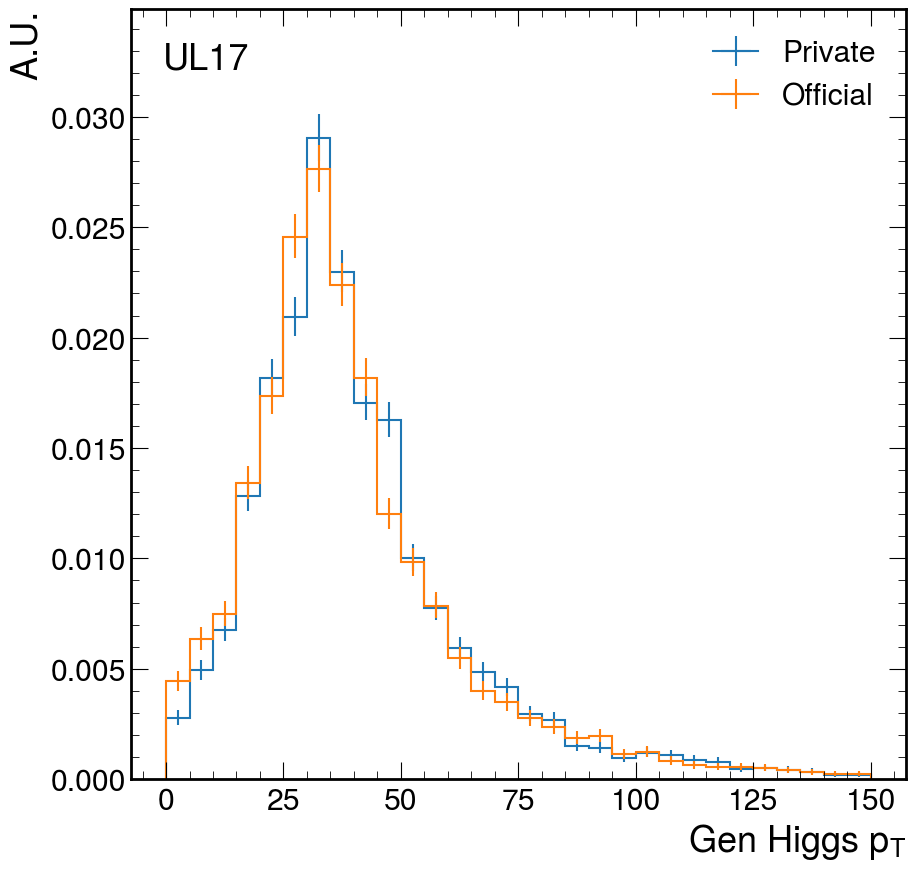

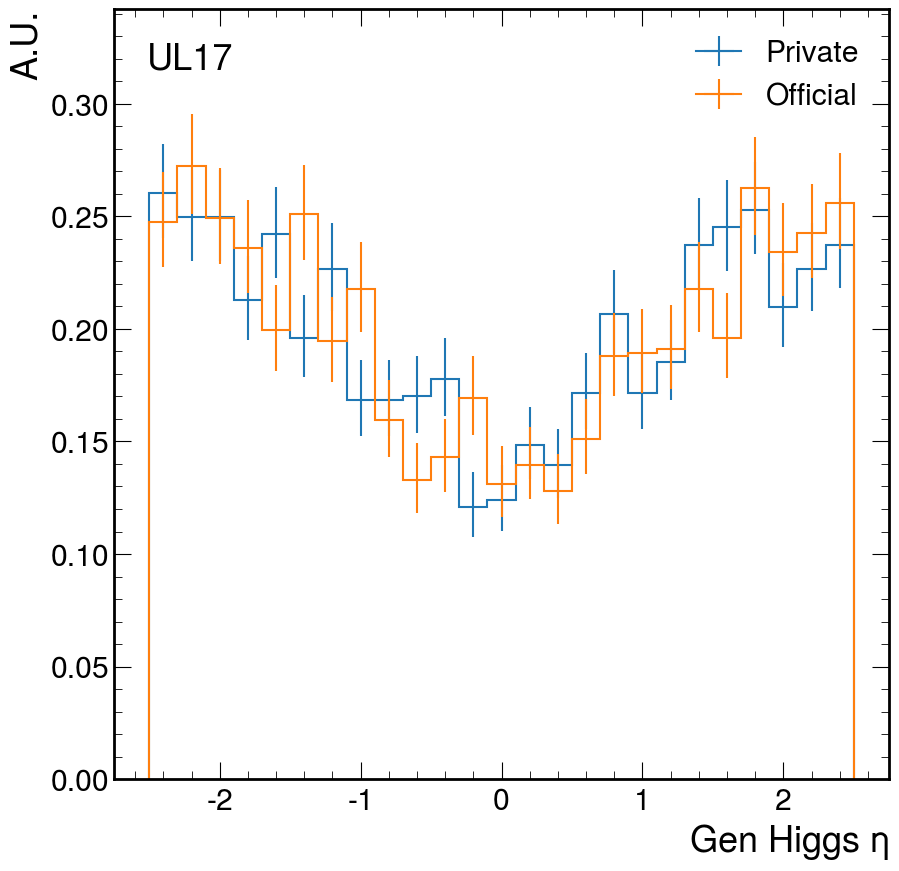

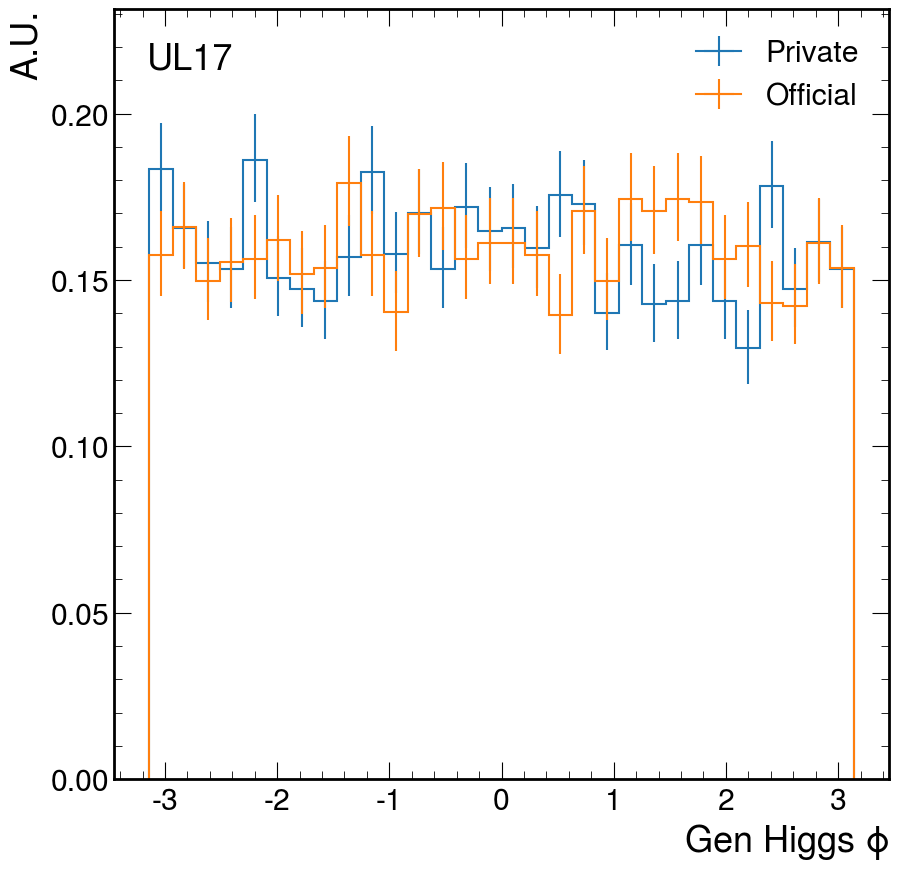

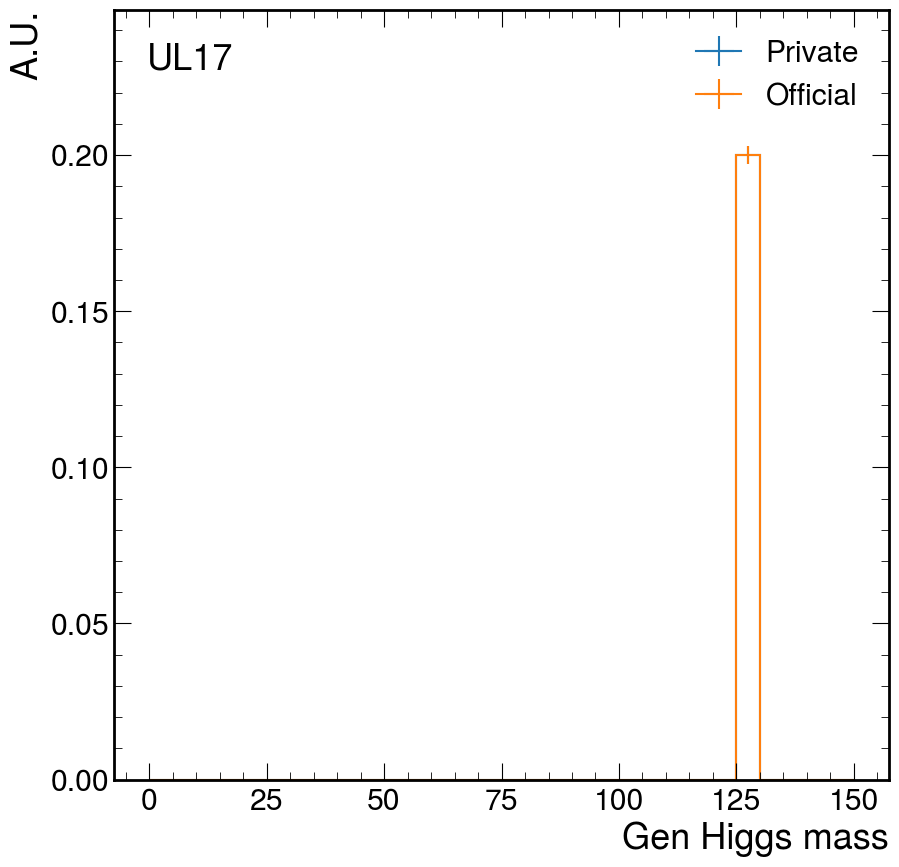

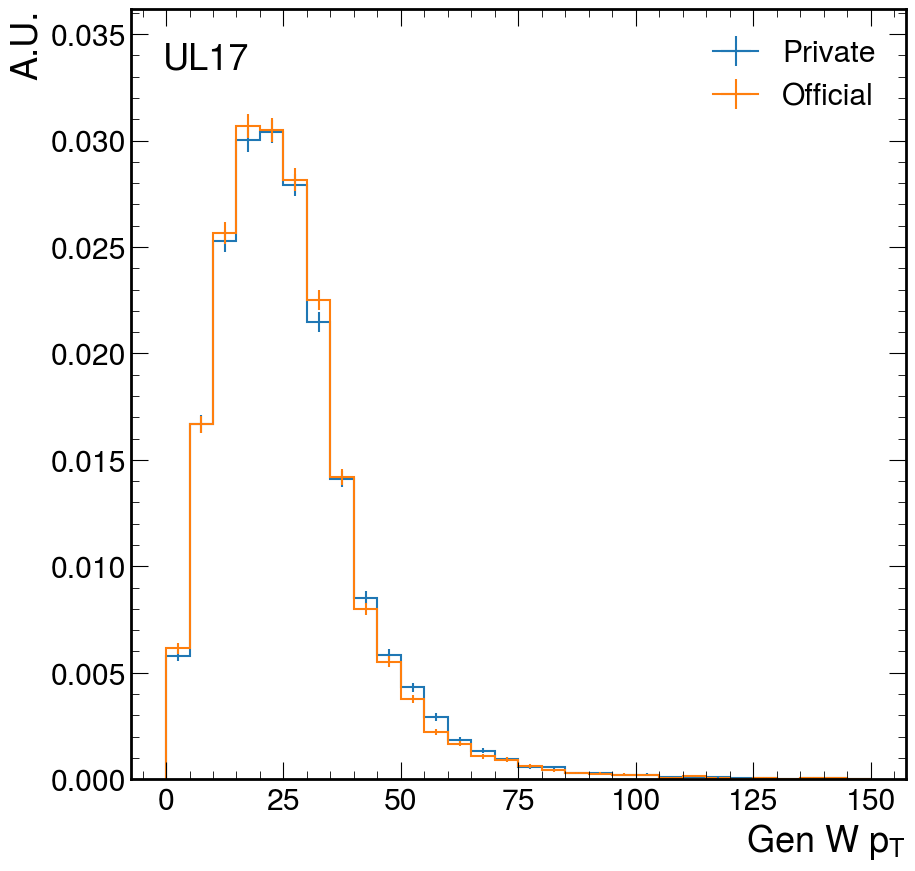

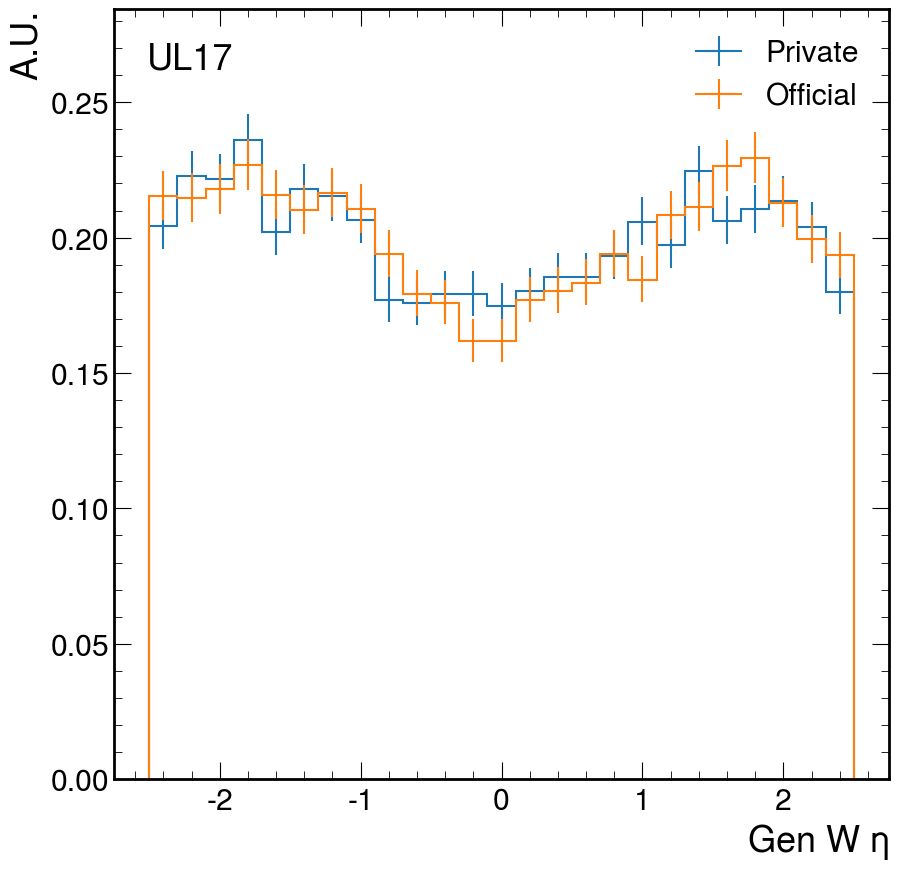

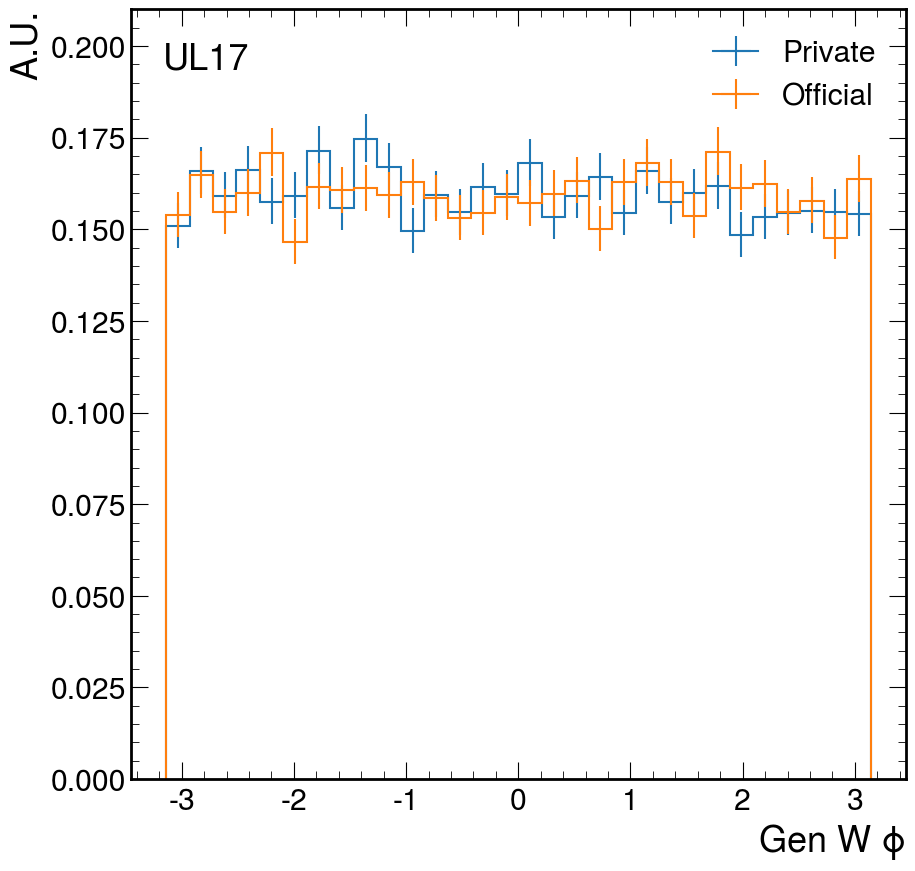

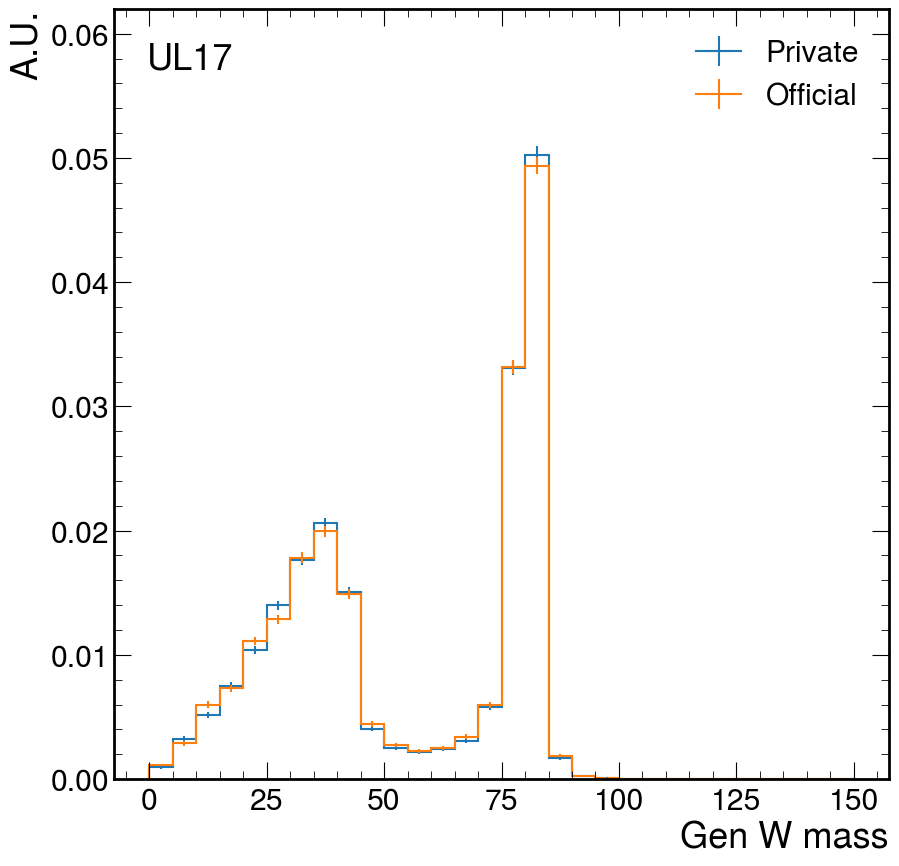

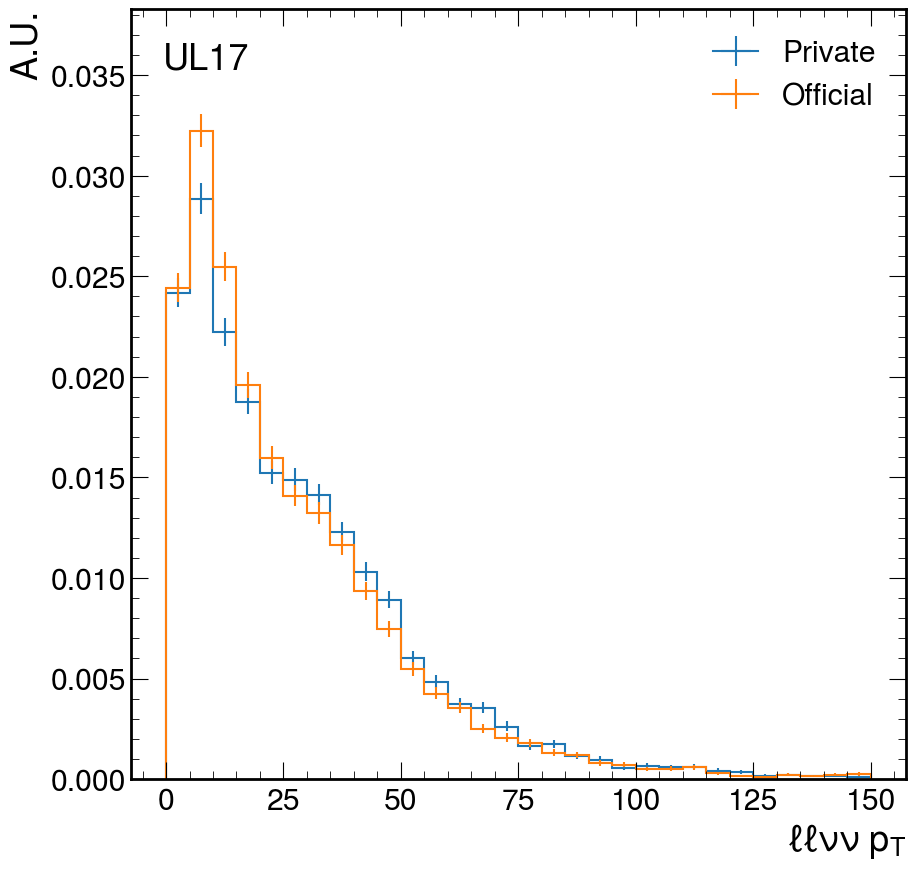

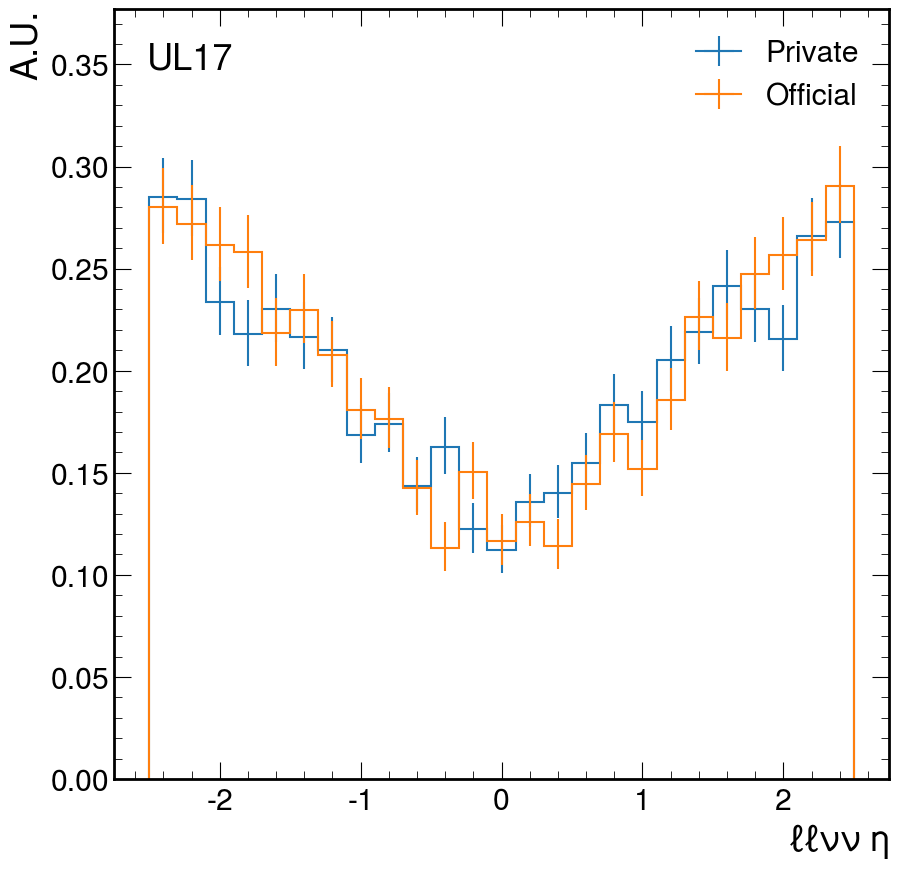

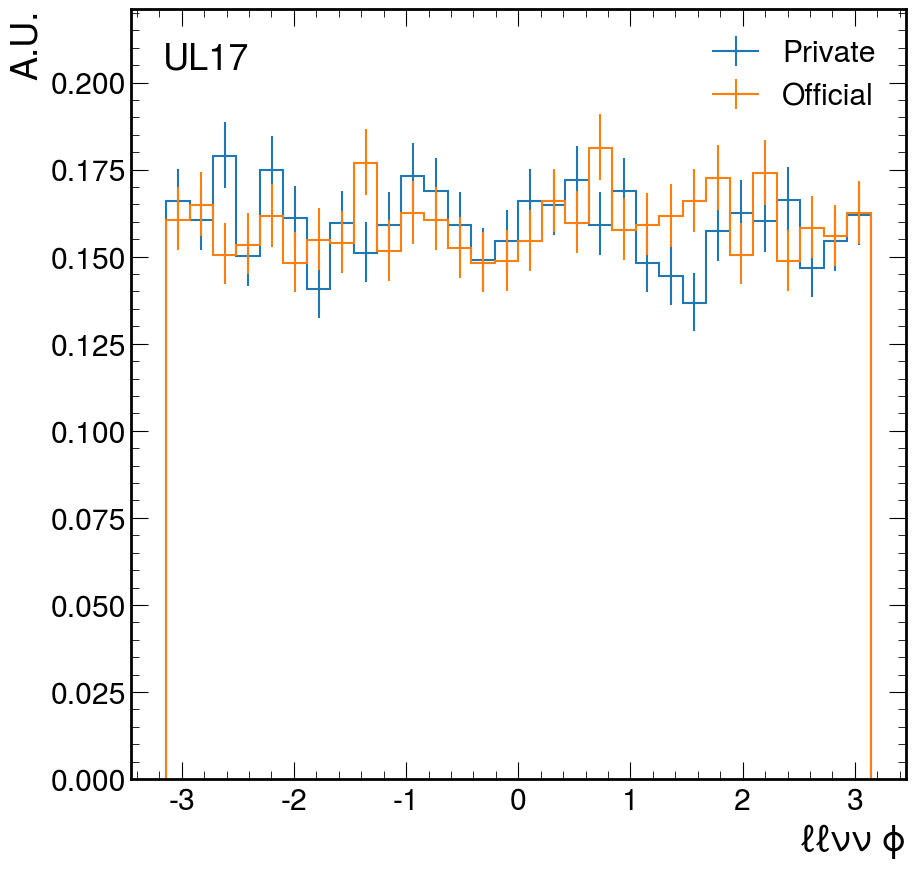

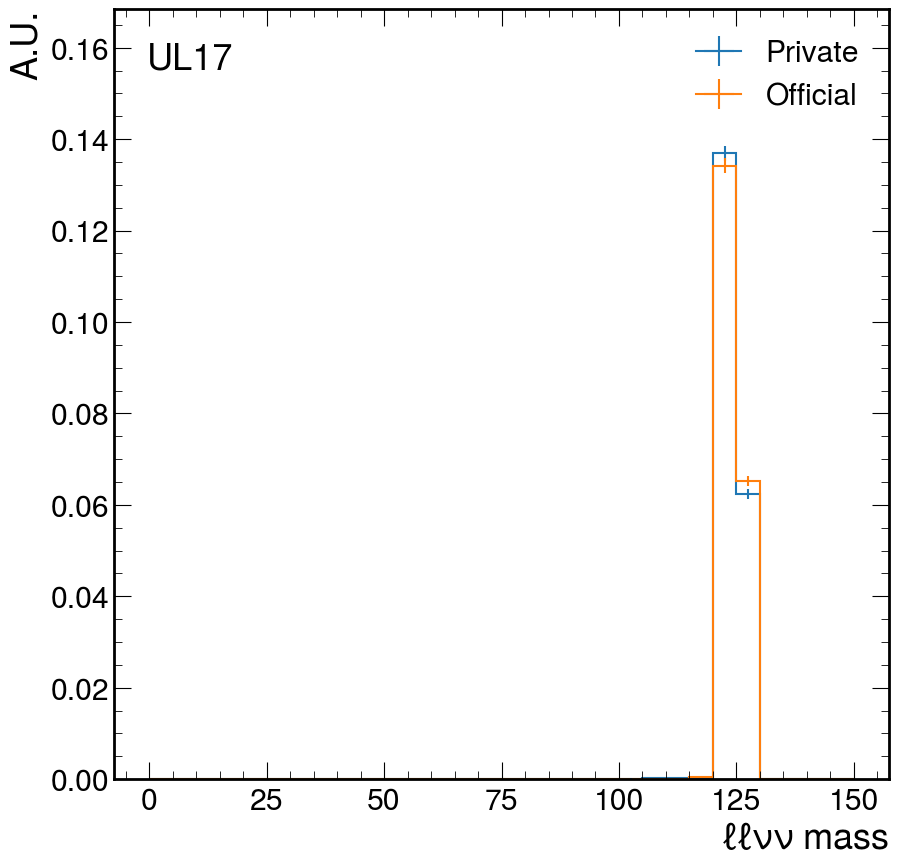

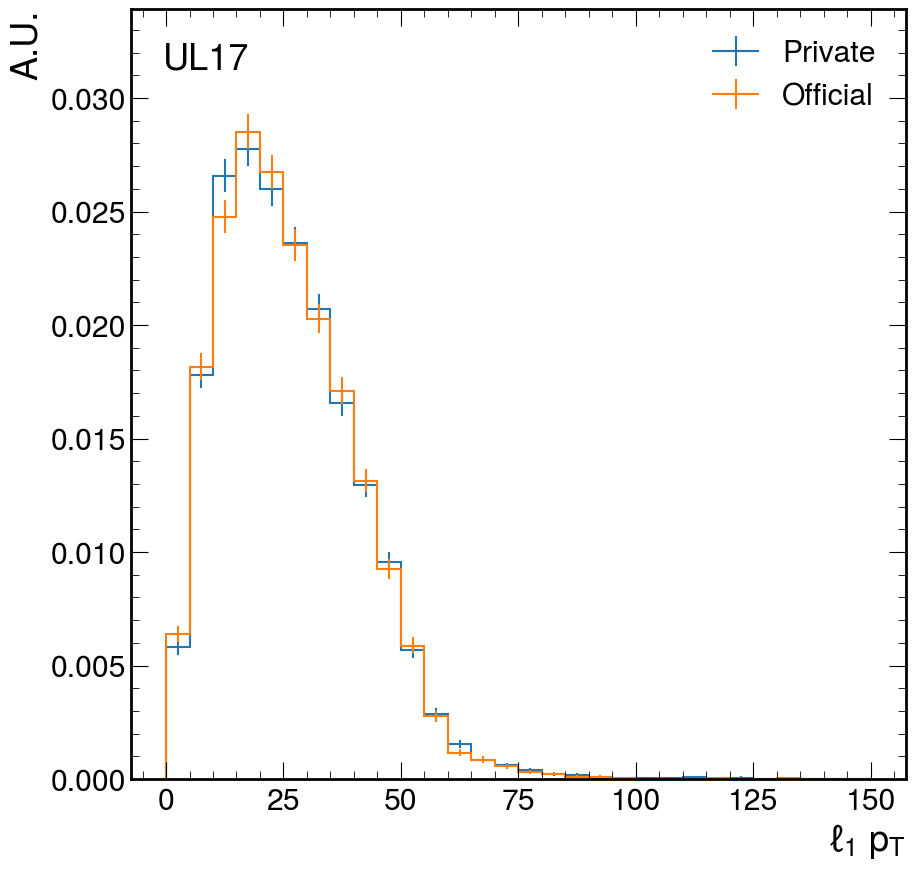

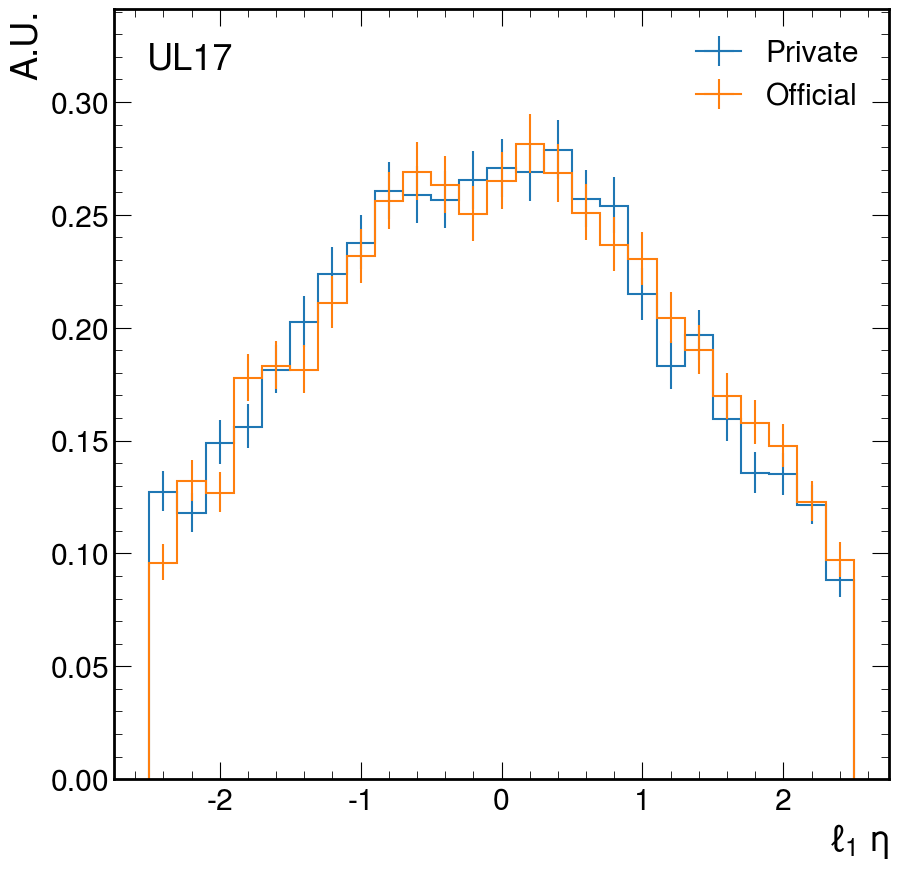

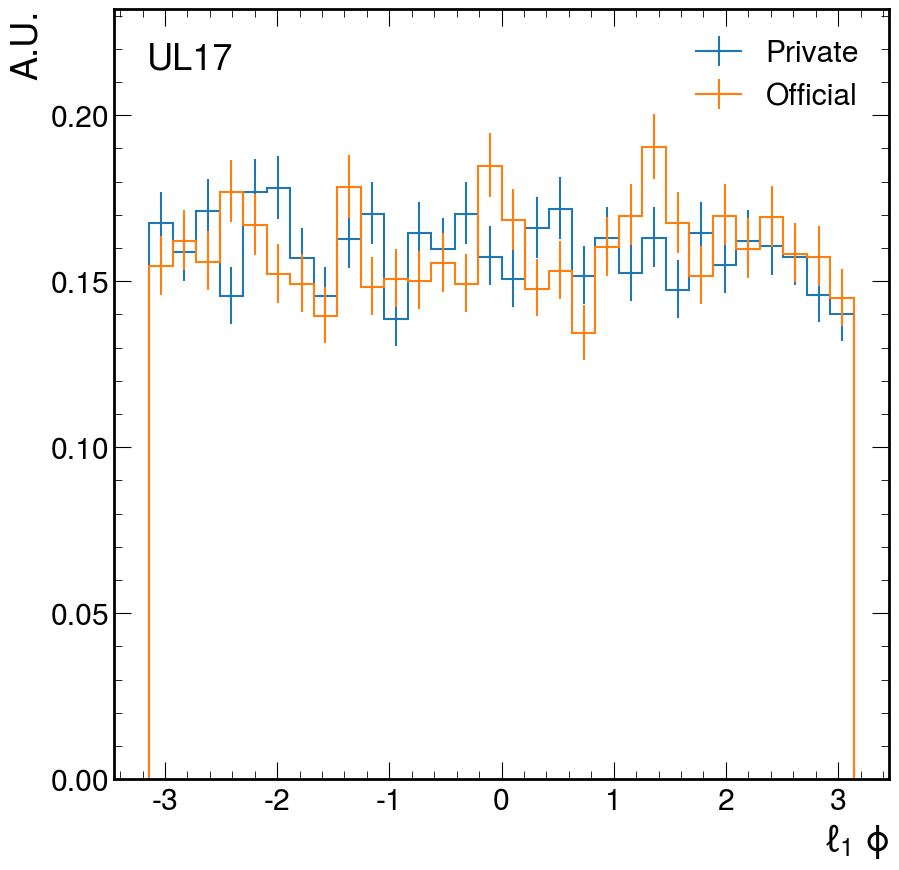

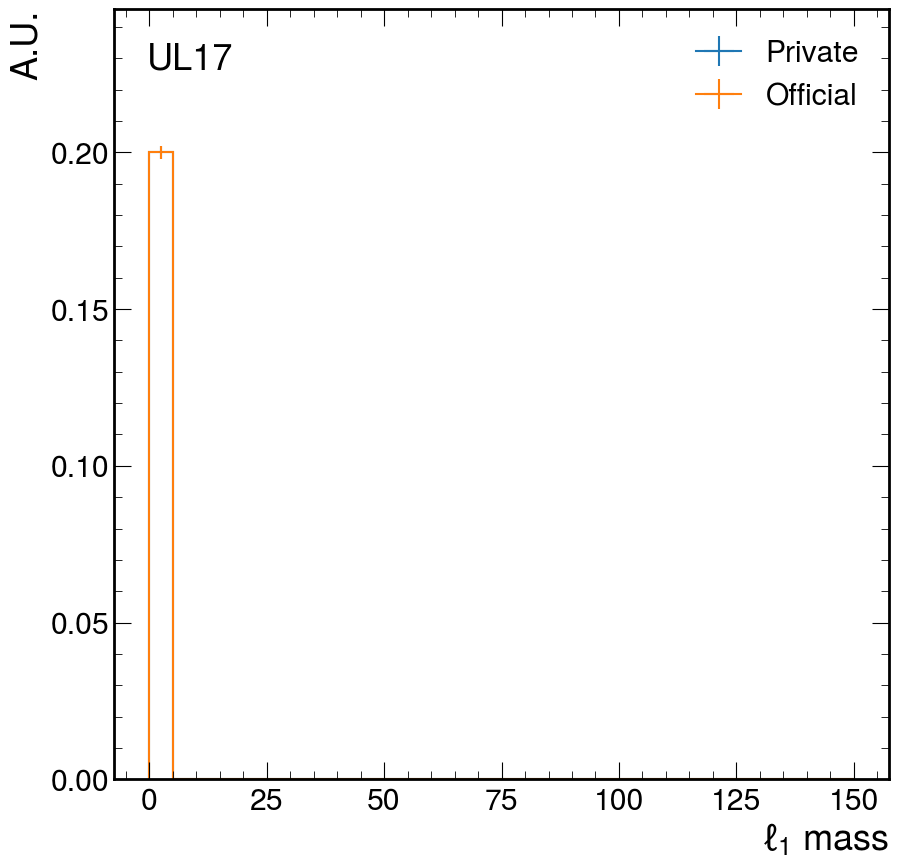

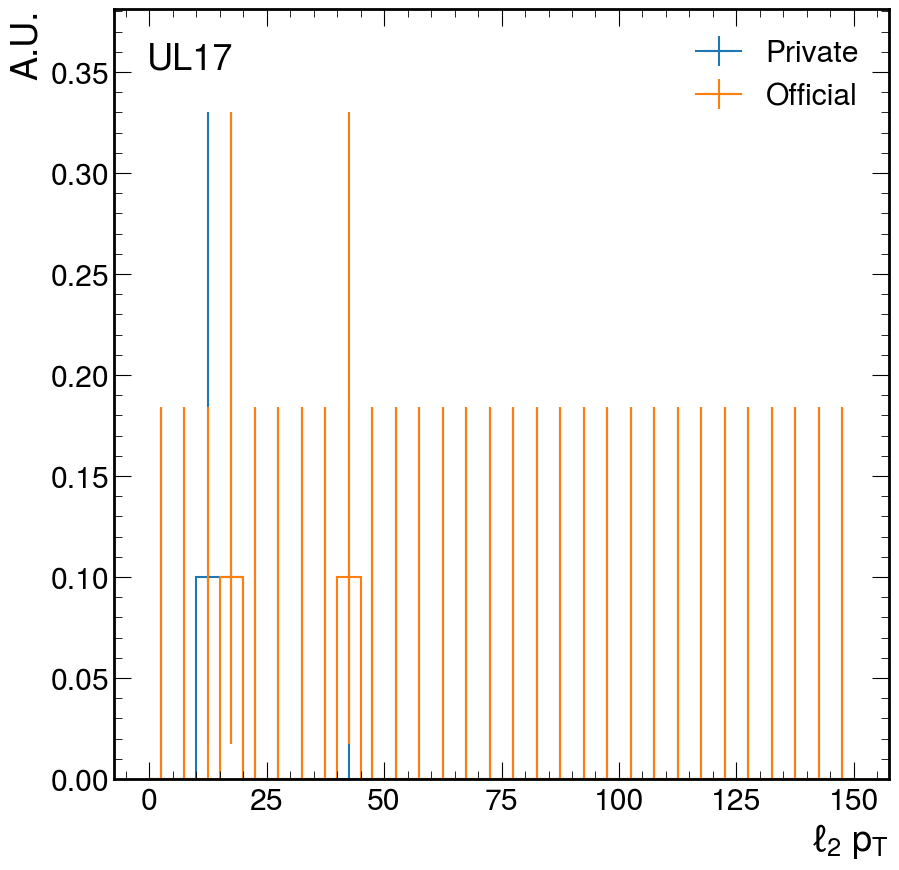

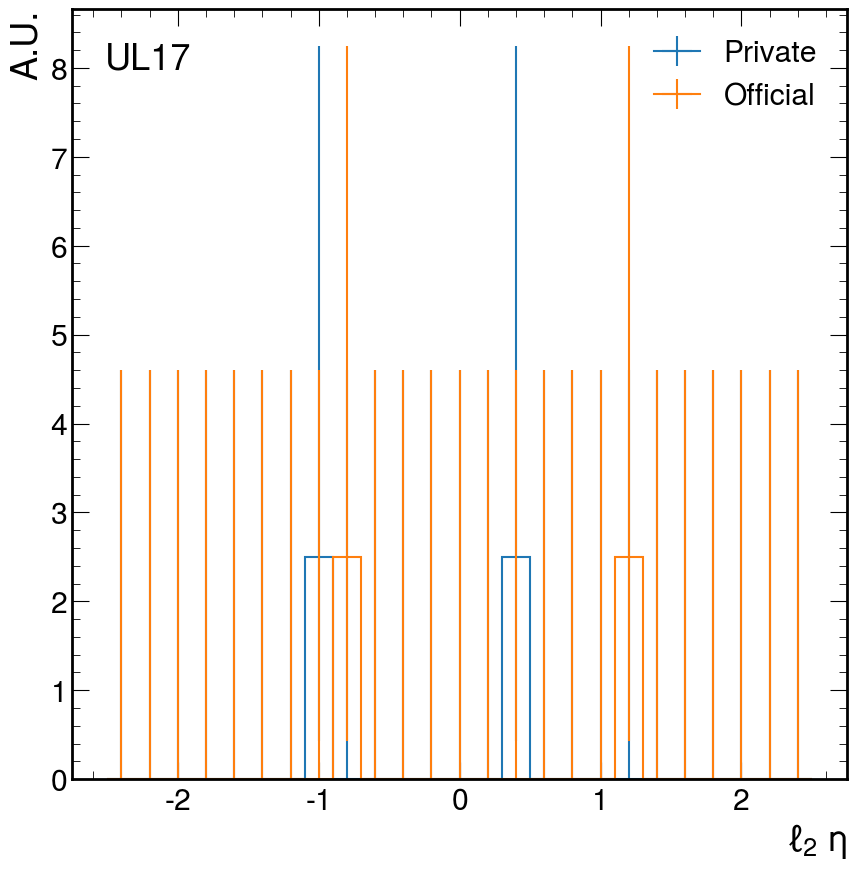

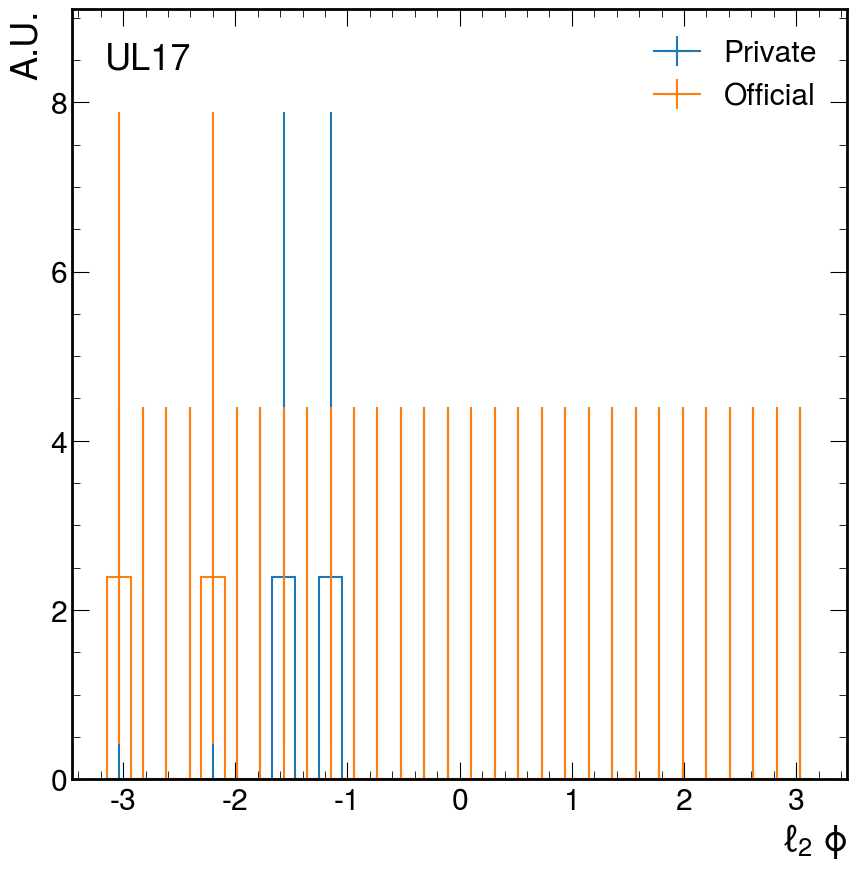

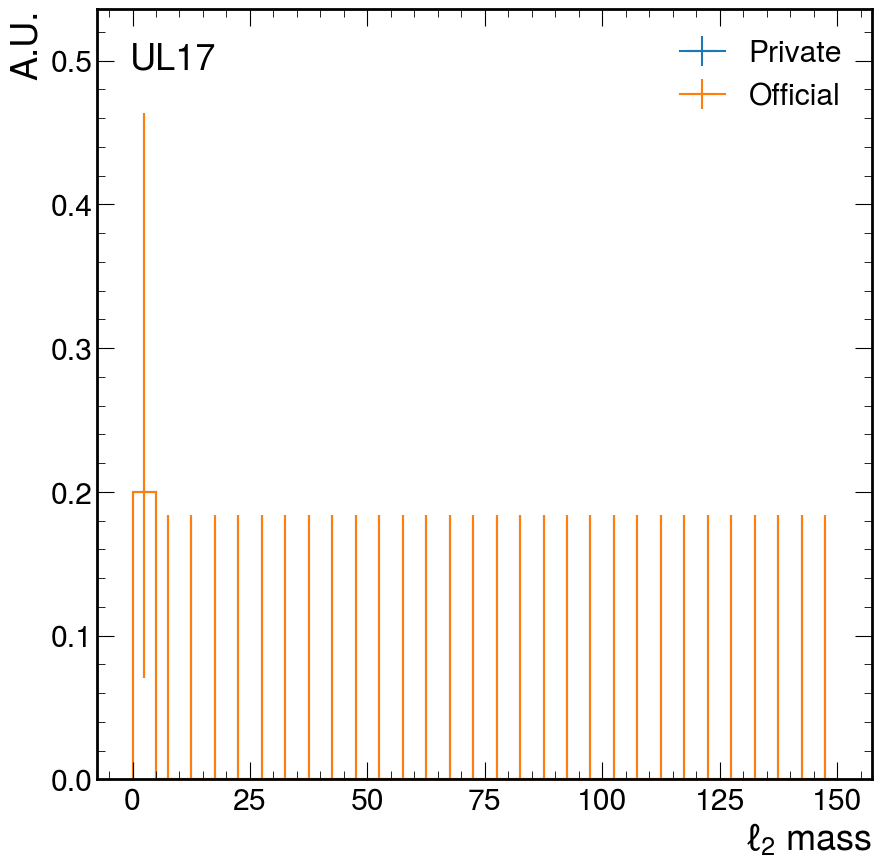

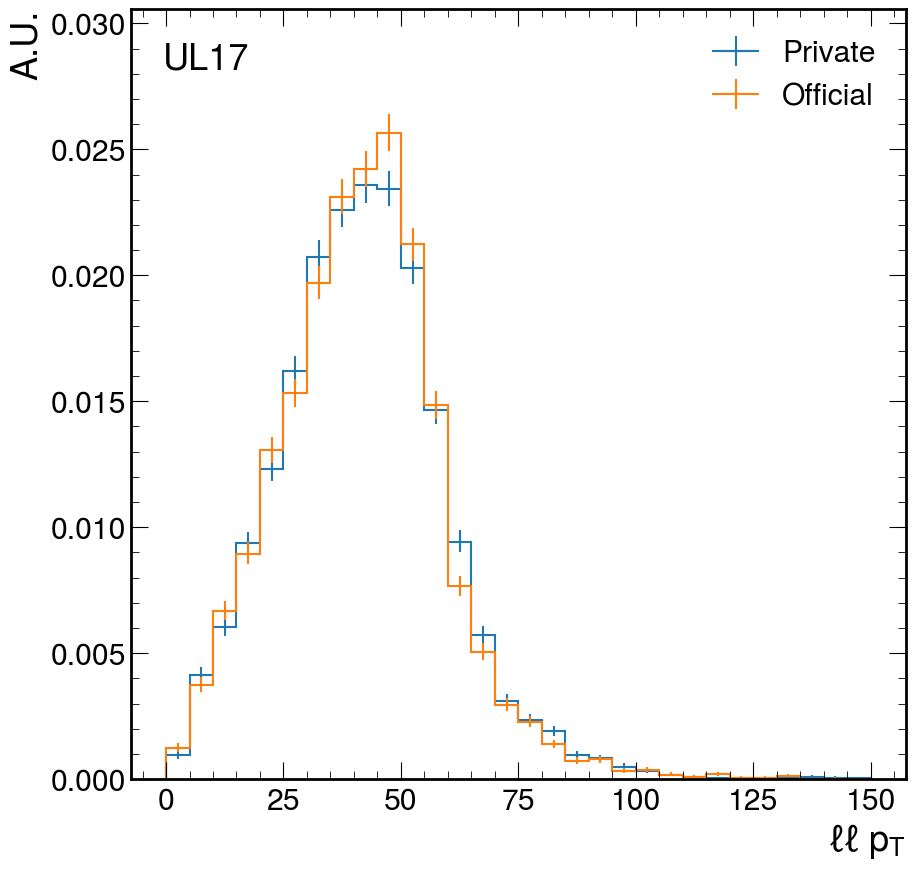

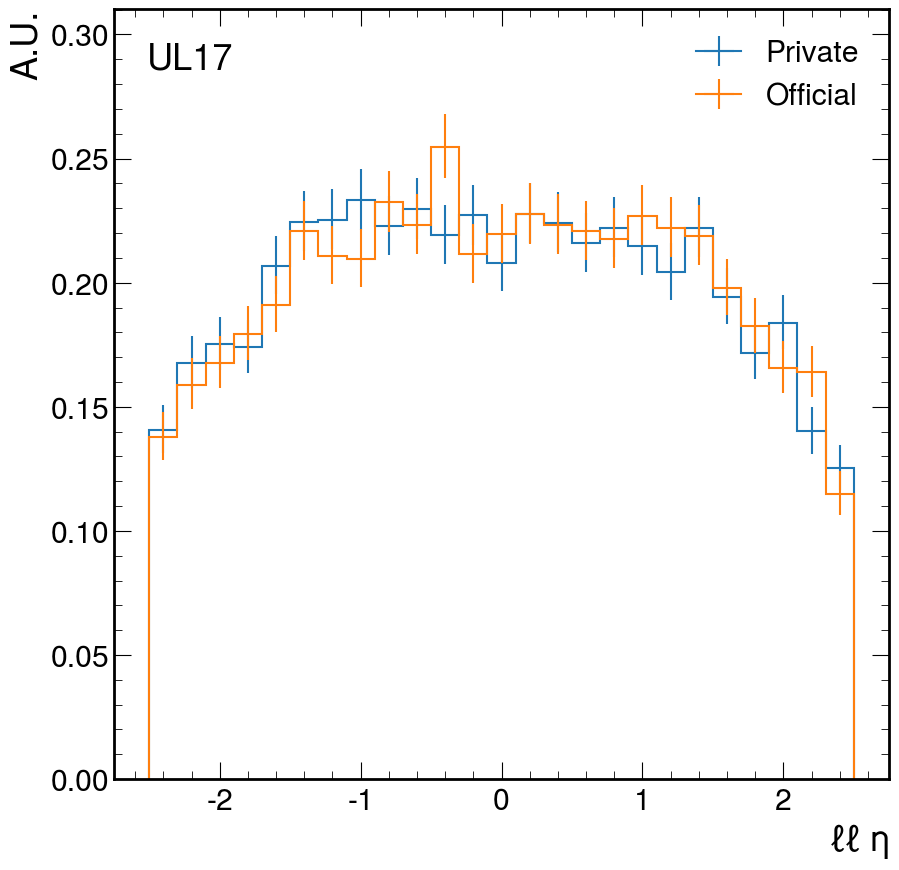

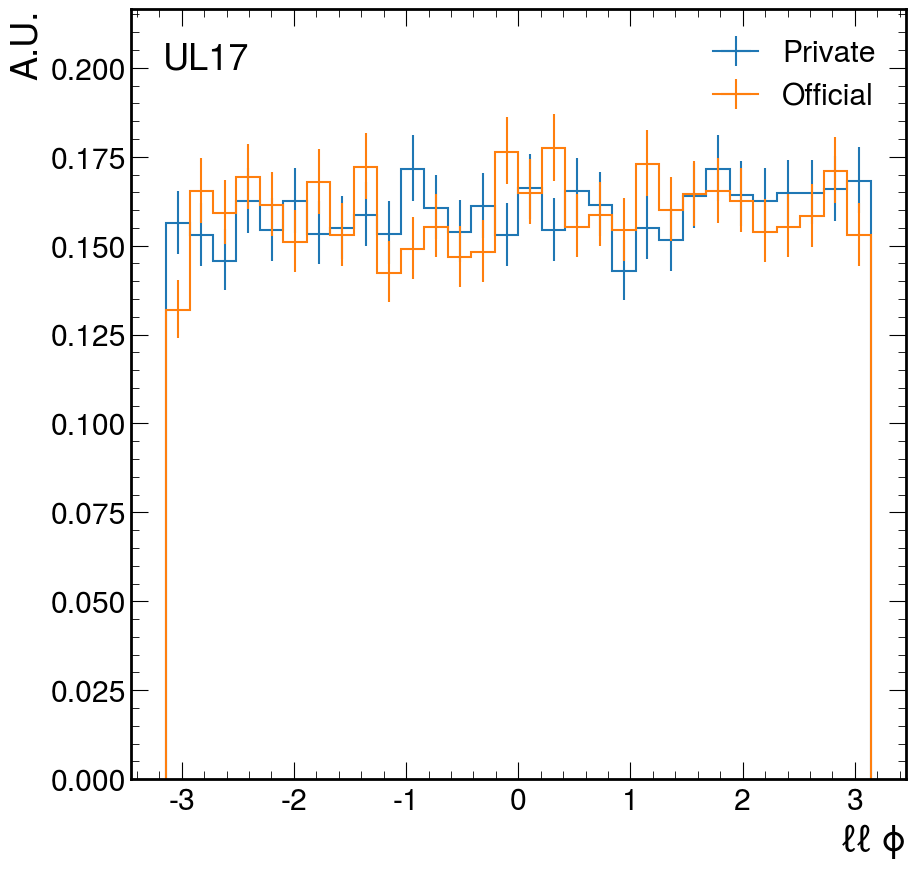

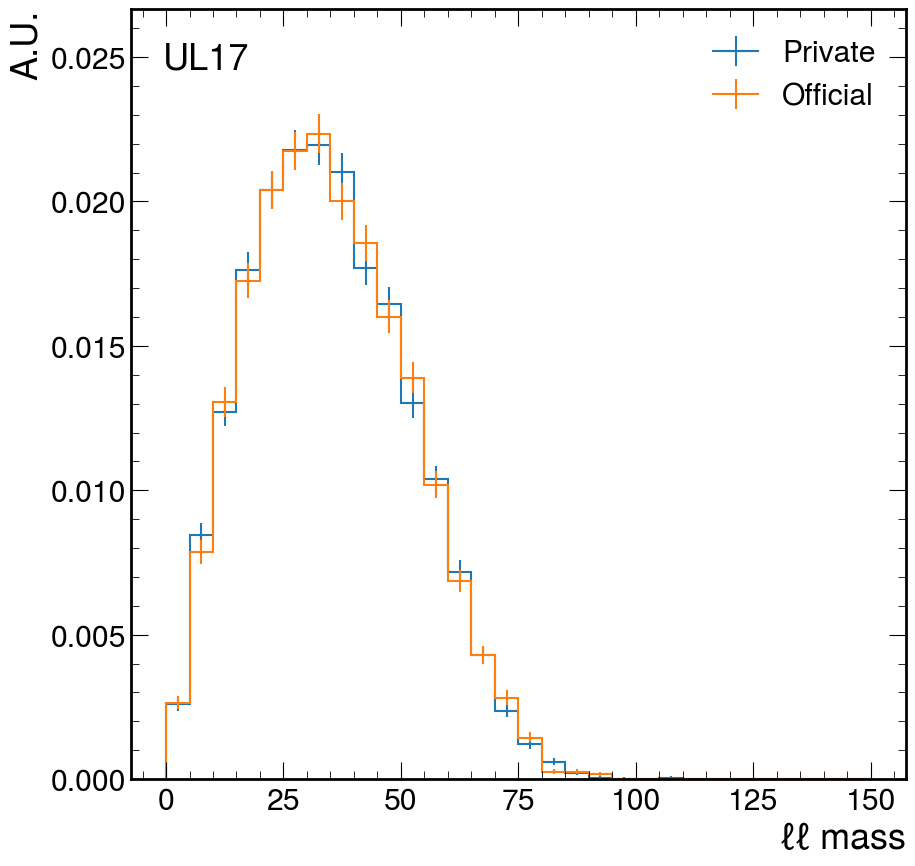

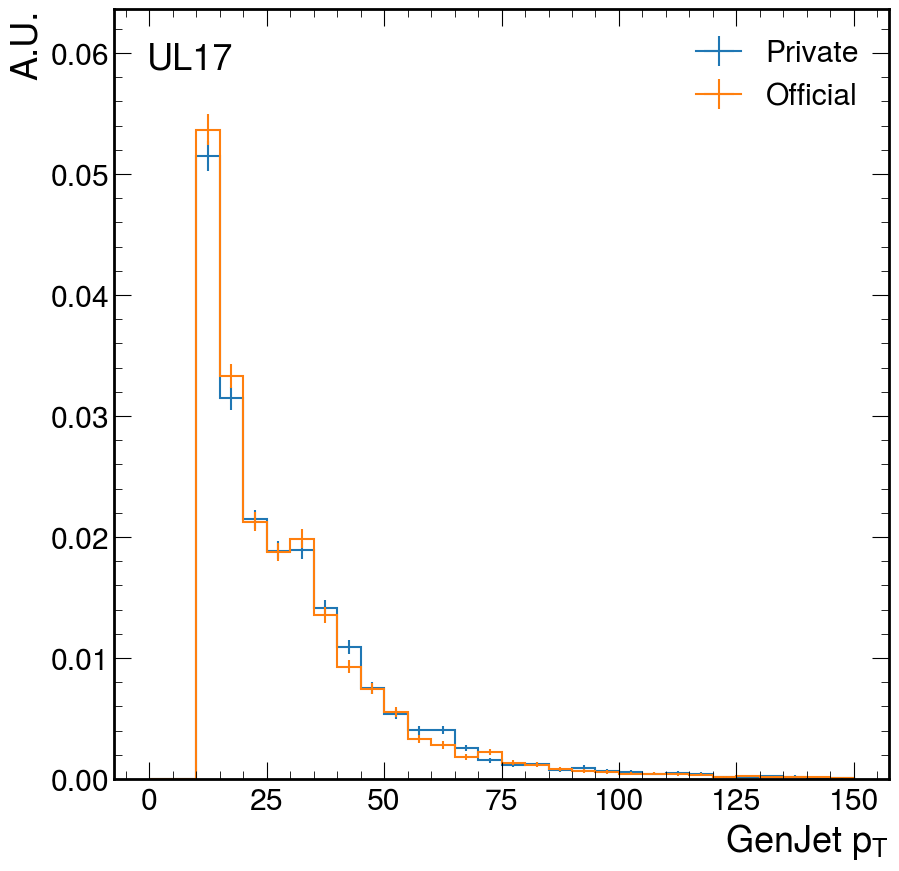

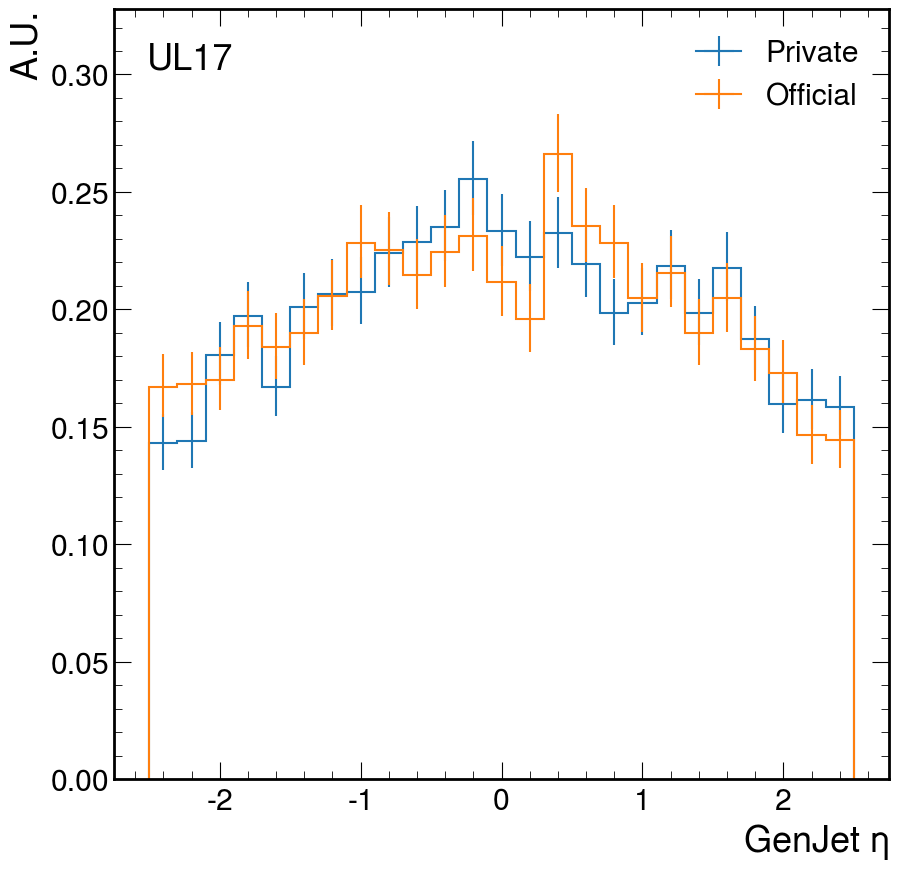

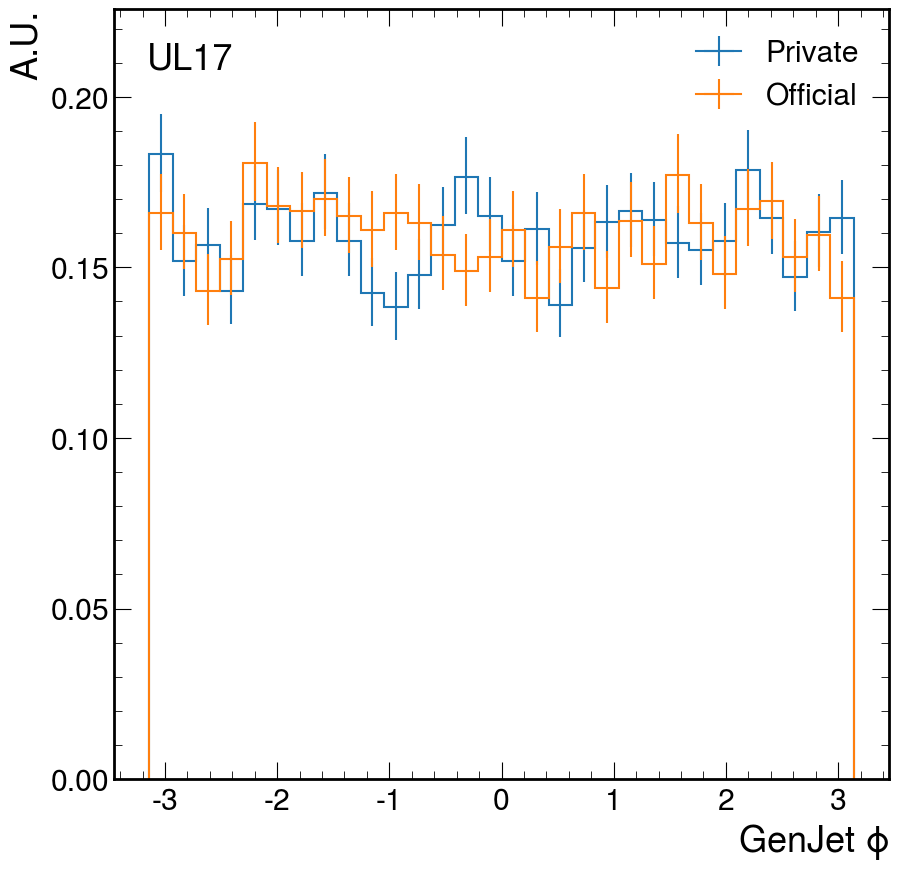

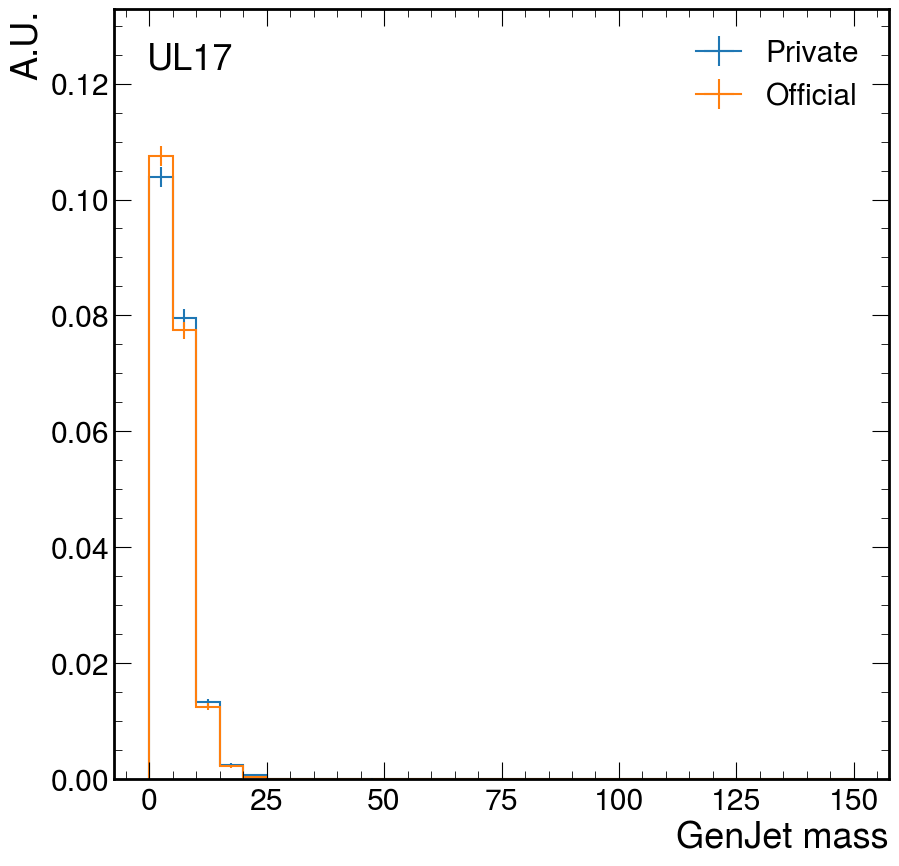

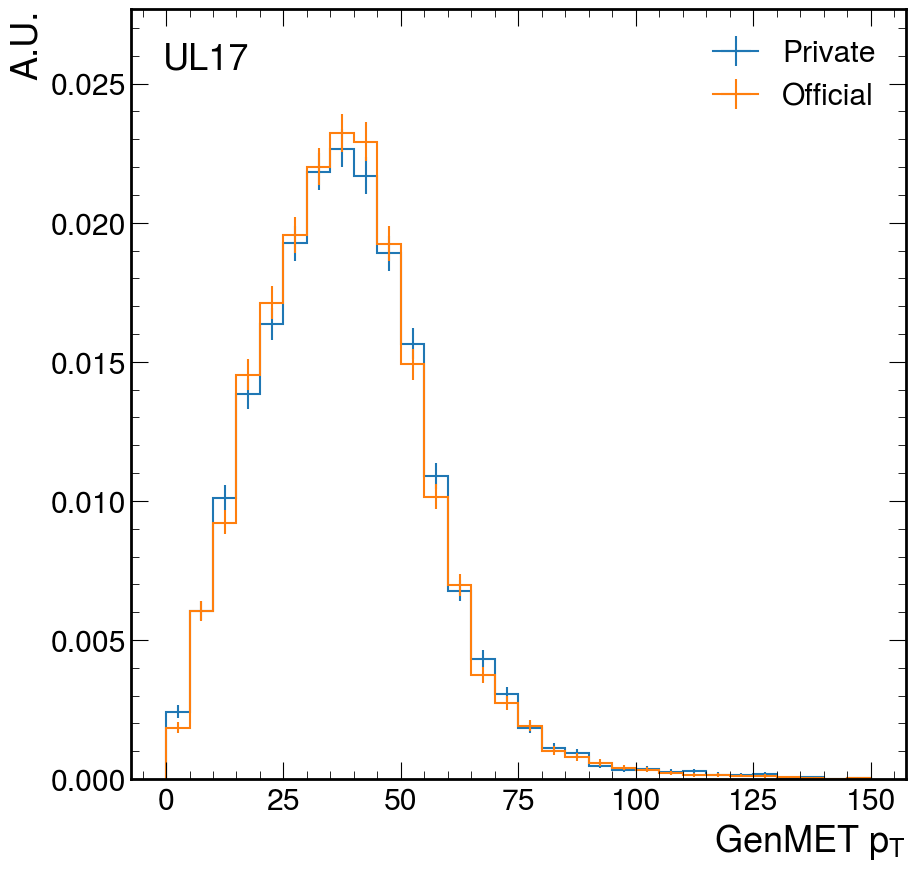

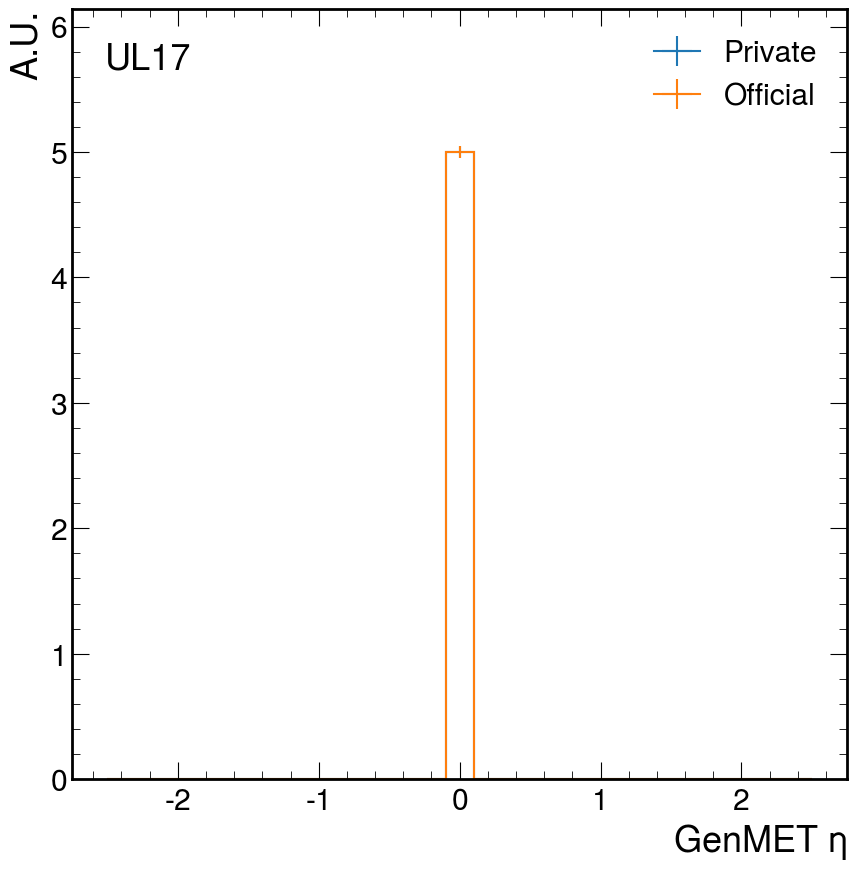

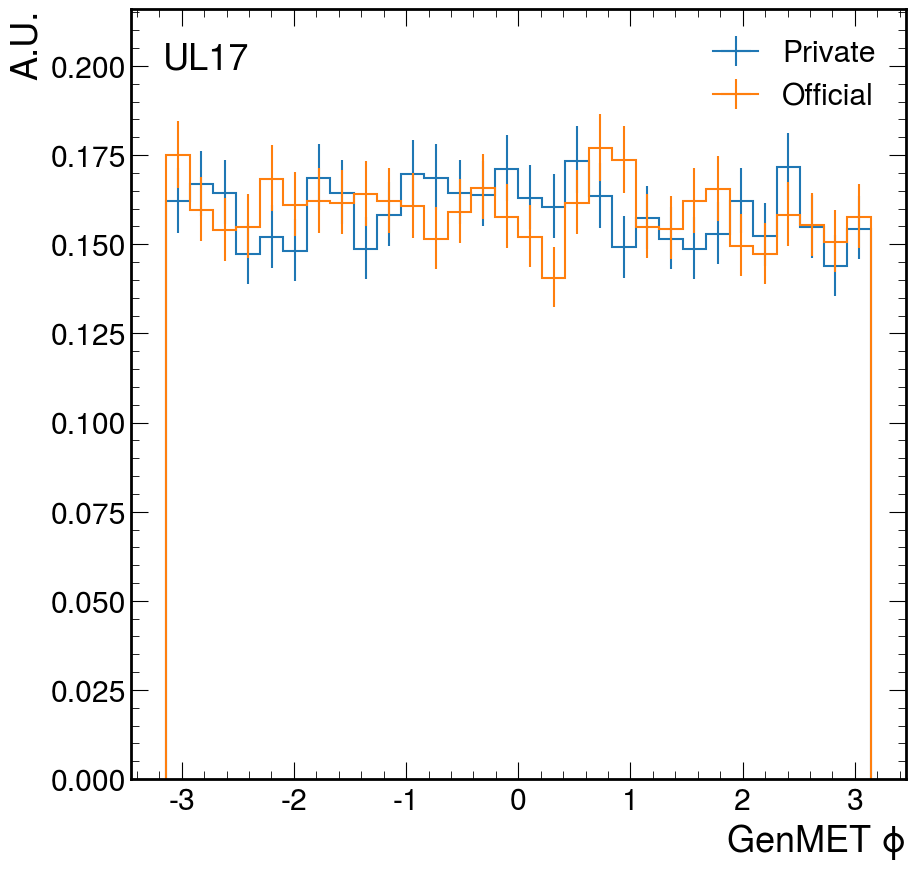

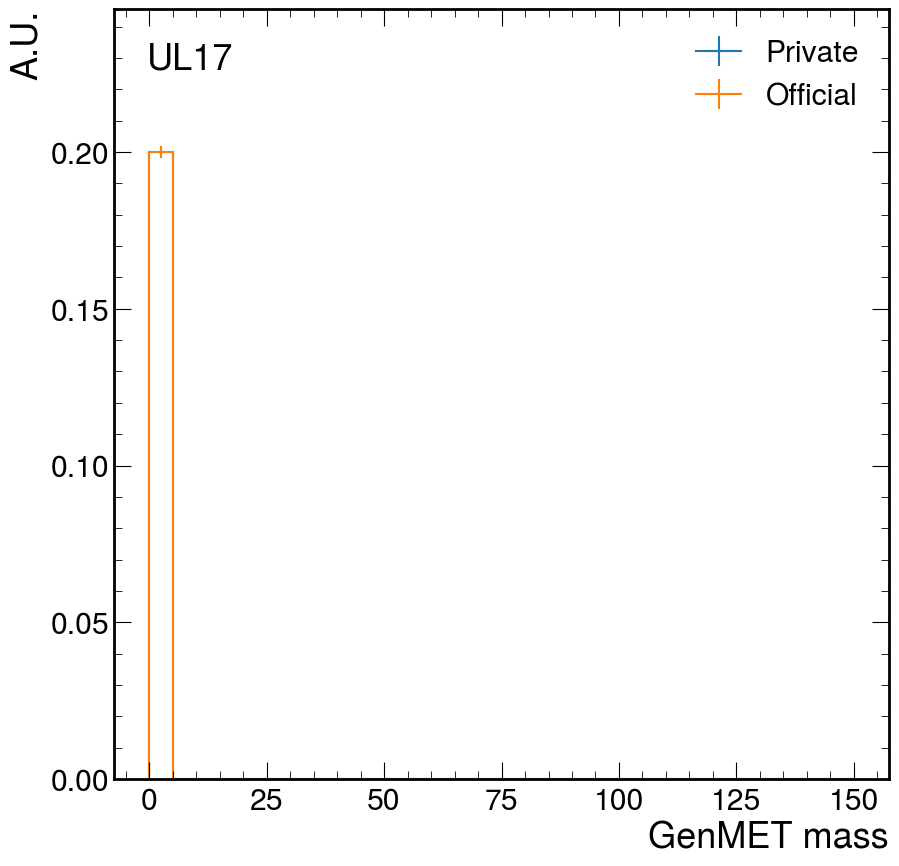

In [93]:

import hist
import mplhep as hep
old={
    "Gen Higgs":H,
    "Gen W":W,
    "$\\ell\\ell\\nu\\nu$":(W_lep[:,0]+W_lep[:,1]+W_neu[:,0]+W_neu[:,1]),
#     "Reco W1":(W_lep[:,0]+W_neu[:,0]),
#     "Reco W2" :(W_lep[:,1]+W_neu[:,1]),
    '$\\ell_1$':W_lep[:,0],'$\\ell_2$':W_lep[:1],
    '$\\ell\\ell$':(W_lep[:,0]+W_lep[:,1]),
    'GenJet':genjet,
    'GenMET':genmet
}
new={
    "Gen Higgs":H_new,
    "Gen W":W_new,
    "$\\ell\\ell\\nu\\nu$":(W_lep_new[:,0]+W_lep_new[:,1]+W_neu_new[:,0]+W_neu_new[:,1]),
#     "Reco W1":(W_lep_new[:,0]+W_neu_new[:,0]),
#     "$\\ell^1+$" :(W_lep_new[:,1]+W_neu_new[:,1]),
    '$\\ell_1$':W_lep_new[:,0],'$\\ell_2$':W_lep_new[:1],
    '$\\ell\\ell$':(W_lep_new[:,0]+W_lep_new[:,1]),
    'GenJet':genjet_new,
    'GenMET':genmet_new
}
binning={
    'pt':[30, 0, 150],
    'eta':[25, -2.5, 2.5],
    'phi':[30, -3.14, 3.14],
    'mass':[30, 0,150]
}
labelmap={"pt":"$p_T$",'eta':"$\\eta$",'phi':"$\\phi$", "mass":"mass"}
plt.style.use(hep.style.ROOT)
from matplotlib.offsetbox import AnchoredText
for obj in new.keys():
    for var in binnings.keys():
        print(obj,var)
#         hold,hnew=binnings[var],binnings[var]
        if 'pt' not in old[obj].fields:
            old[obj]['pt']=old[obj].pt
            old[obj]['eta']=old[obj].eta
            old[obj]['phi']=old[obj].phi
            old[obj]['mass']=old[obj].mass
        if 'pt' not in new[obj].fields:
            new[obj]['pt']=new[obj].pt
            new[obj]['eta']=new[obj].eta
            new[obj]['phi']=new[obj].phi
            new[obj]['mass']=new[obj].mass
        hold = hist.Hist.new.Reg(binning[var][0],binning[var][1],binning[var][2]).Weight()
        hnew = hist.Hist.new.Reg(binning[var][0],binning[var][1],binning[var][2]).Weight()
        fig,ax=plt.subplots()
        hold.fill(ak.flatten(old[obj][var],axis=-1))
        hnew.fill(ak.flatten(new[obj][var],axis=-1))#,weight=1.06*ak.ones_like(ak.flatten(new[obj][var],axis=-1)))
        hep.histplot([hold,hnew],label=['Private','Official'],ax=ax,flow=None,density=True)
#         hep.histplot(hnew,label='new',ax=ax,flow=None)#,clear=False)
        ax.set_xlabel(f'{obj} {labelmap[var]}')
        ax.set_ylabel("A.U.")
        ax.legend()
        at = AnchoredText("UL17",  frameon=False,loc=2)
        ax.add_artist(at)
        hep.mpl_magic(ax=ax)
        fig.savefig(f'plot/GEN_0425_ULoff/{obj}_{labelmap[var]}.pdf')


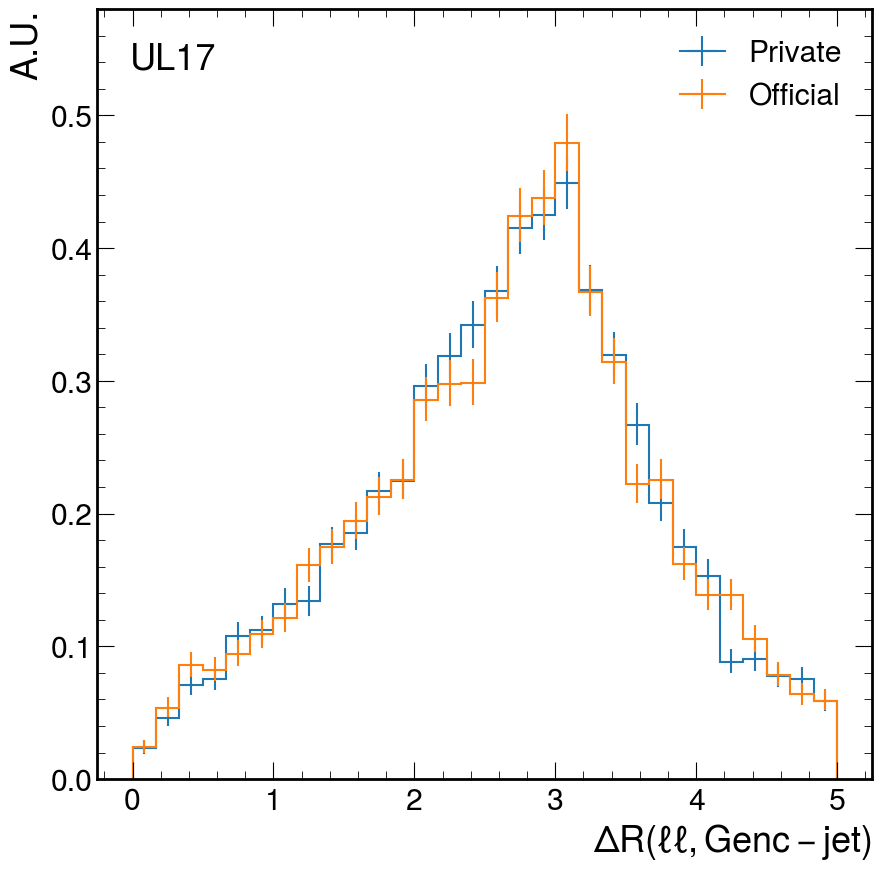

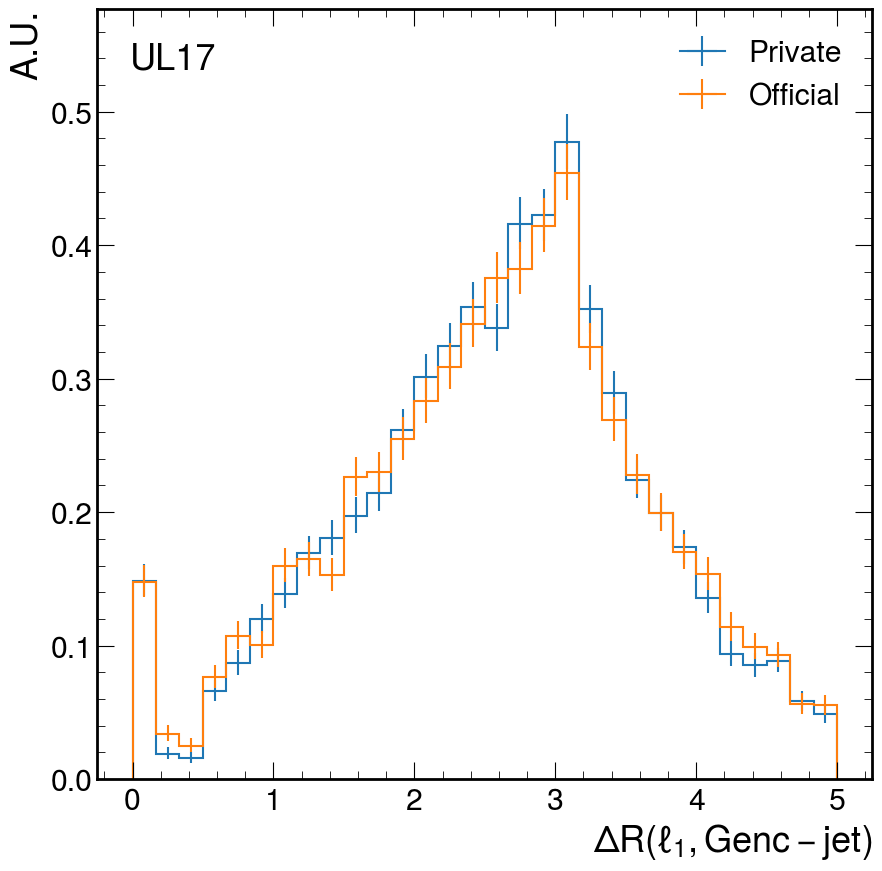

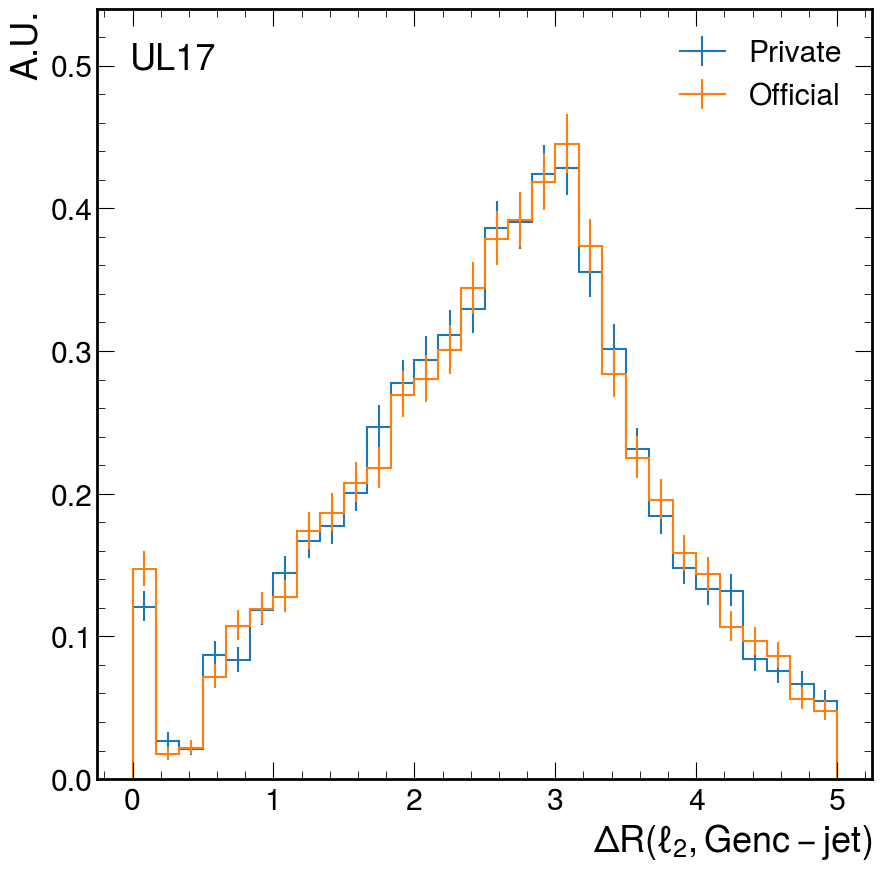

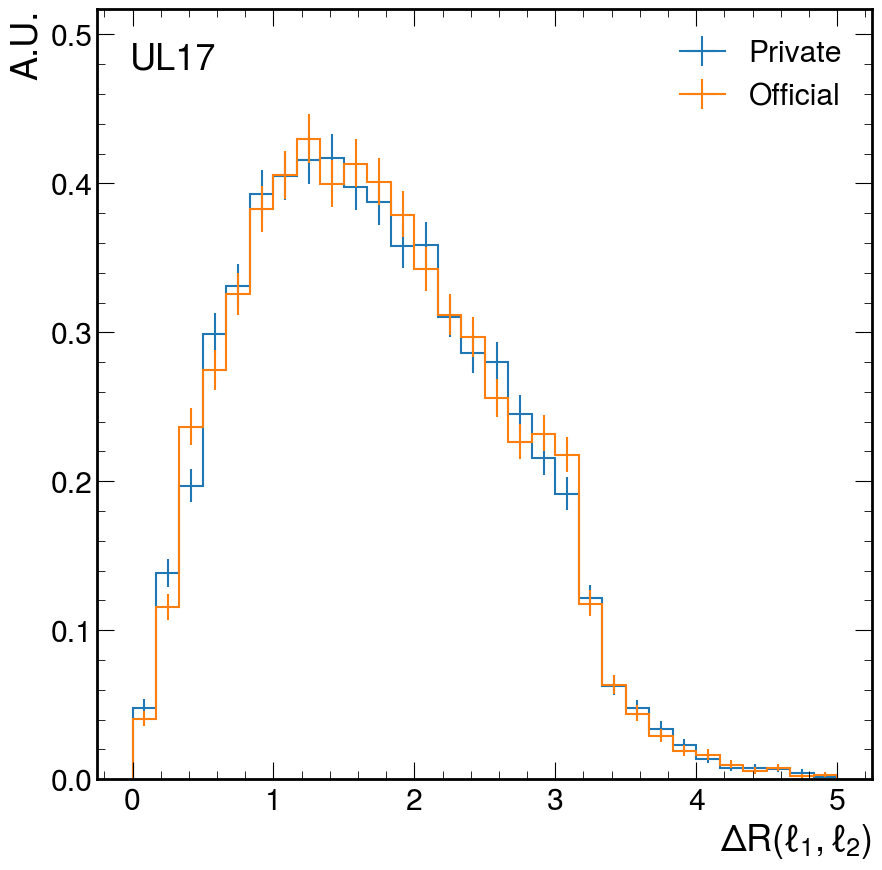

In [100]:
dr_comb_old={
    "$\\Delta R(\\ell\\ell,Gen c-jet)$":[(W_lep[:,0]+W_lep[:,1]),genjet],
    "$\\Delta R(\\ell_1,Gen c-jet)$":[(W_lep[:,0]),genjet],
    "$\\Delta R(\\ell_2,Gen c-jet)$":[(W_lep[:,1]),genjet],
    "$\\Delta R(\\ell_1,\\ell_2)$":[(W_lep[:,0]),W_lep[:,1]],
}
dr_comb_new={
    "$\\Delta R(\\ell\\ell,Gen c-jet)$":[(W_lep_new[:,0]+W_lep_new[:,1]),genjet_new],
    "$\\Delta R(\\ell_1,Gen c-jet)$":[(W_lep_new[:,0]),genjet_new],
    "$\\Delta R(\\ell_2,Gen c-jet)$":[(W_lep_new[:,1]),genjet_new],
    "$\\Delta R(\\ell_1,\\ell_2)$":[(W_lep_new[:,0]),W_lep_new[:,1]],
}
for var in dr_comb_new.keys():
    hold = hist.Hist.new.Reg(30,0,5).Weight()
    hnew = hist.Hist.new.Reg(30,0,5).Weight()
    fig,ax=plt.subplots()
    hold.fill(ak.flatten(dr_comb_old[var][0].delta_r(dr_comb_old[var][1]),axis=-1))
    hnew.fill(ak.flatten(dr_comb_new[var][0].delta_r(dr_comb_new[var][1]),axis=-1))
    hep.histplot([hold,hnew],label=['Private','Official'],ax=ax,flow=None,density=True)
    #         hep.histplot(hnew,label='new',ax=ax,flow=None)#,clear=False)
    ax.set_xlabel(var)
    ax.set_ylabel("A.U.")
    ax.legend()
    at = AnchoredText("UL17",  frameon=False,loc=2)
    ax.add_artist(at)
    hep.mpl_magic(ax=ax)
    fig.savefig(f'plot/GEN_0425_ULoff/{var}.pdf')

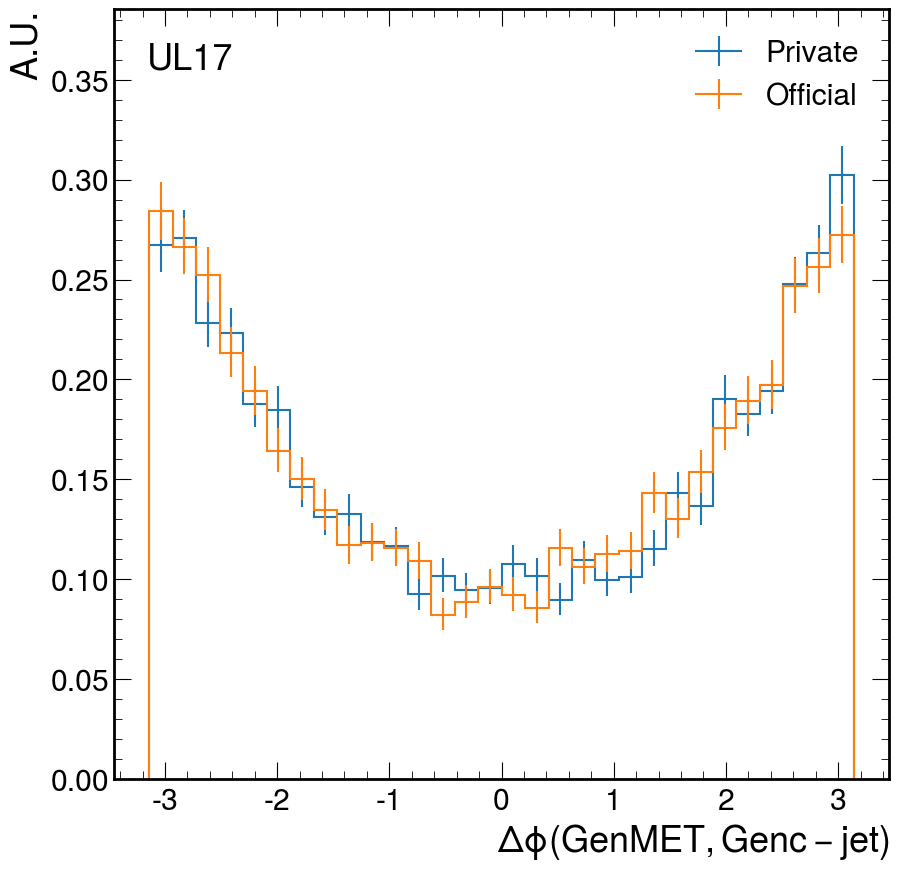

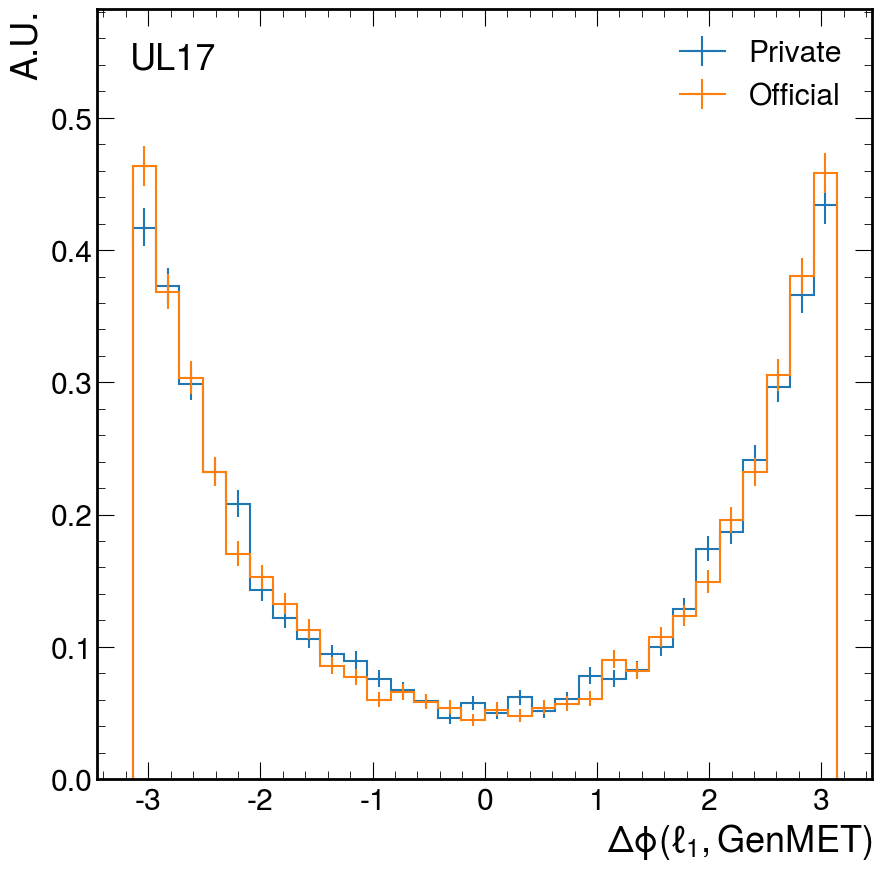

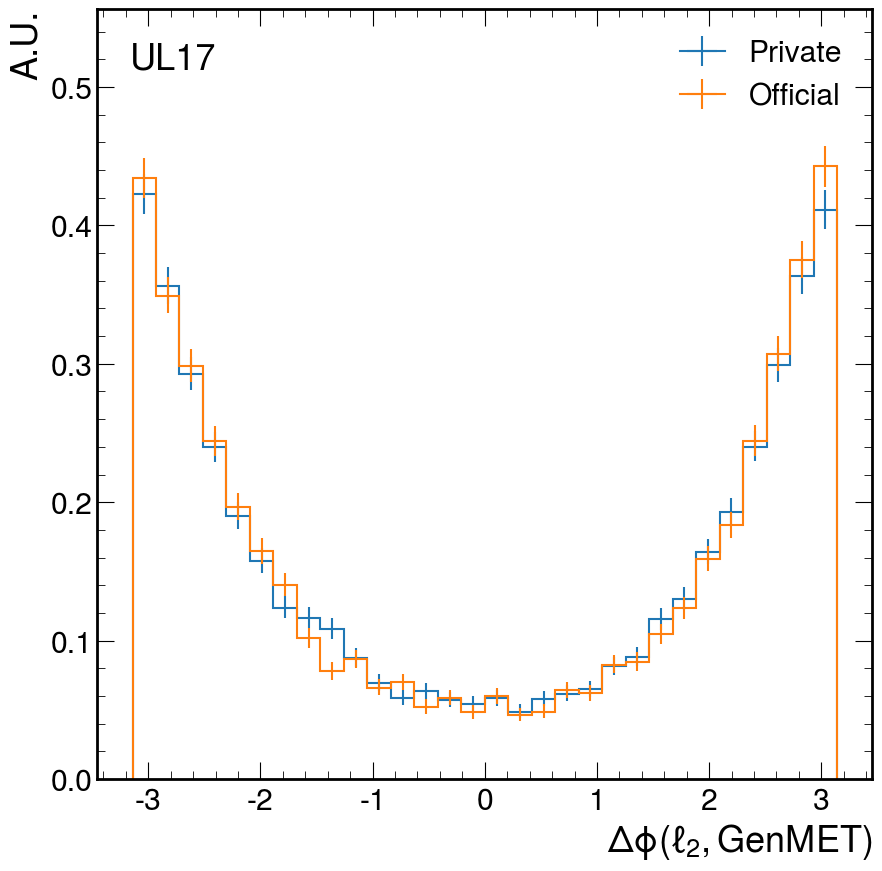

In [104]:
dphi_comb_old={
    "$\\Delta\\phi(GenMET,Gen c-jet)$":[genmet,genjet],
    "$\\Delta\\phi(\\ell_1,GenMET)$":[(W_lep[:,0]),genmet],
    "$\\Delta\\phi(\\ell_2,GenMET)$":[(W_lep[:,1]),genmet],
}
dphi_comb_new={
    "$\\Delta\\phi(GenMET,Gen c-jet)$":[genmet_new,genjet_new],
    "$\\Delta\\phi(\\ell_1,GenMET)$":[(W_lep_new[:,0]),genmet_new],
    "$\\Delta\\phi(\\ell_2,GenMET)$":[(W_lep_new[:,1]),genmet_new],
}
for var in dphi_comb_old.keys():
    hold = hist.Hist.new.Reg(30,-3.14,3.14).Weight()
    hnew = hist.Hist.new.Reg(30,-3.14,3.14).Weight()
    fig,ax=plt.subplots()
    hold.fill(ak.flatten(dphi_comb_old[var][0].delta_phi(dphi_comb_old[var][1]),axis=-1))
    hnew.fill(ak.flatten(dphi_comb_new[var][0].delta_phi(dphi_comb_new[var][1]),axis=-1))
    hep.histplot([hold,hnew],label=['Private','Official'],ax=ax,flow=None,density=True)
    #         hep.histplot(hnew,label='new',ax=ax,flow=None)#,clear=False)
    ax.set_xlabel(var)
    ax.set_ylabel("A.U.")
    ax.legend()
    at = AnchoredText("UL17",  frameon=False,loc=2)
    ax.add_artist(at)
    hep.mpl_magic(ax=ax)
    fig.savefig(f'plot/GEN_0425_ULoff/{var}.pdf')

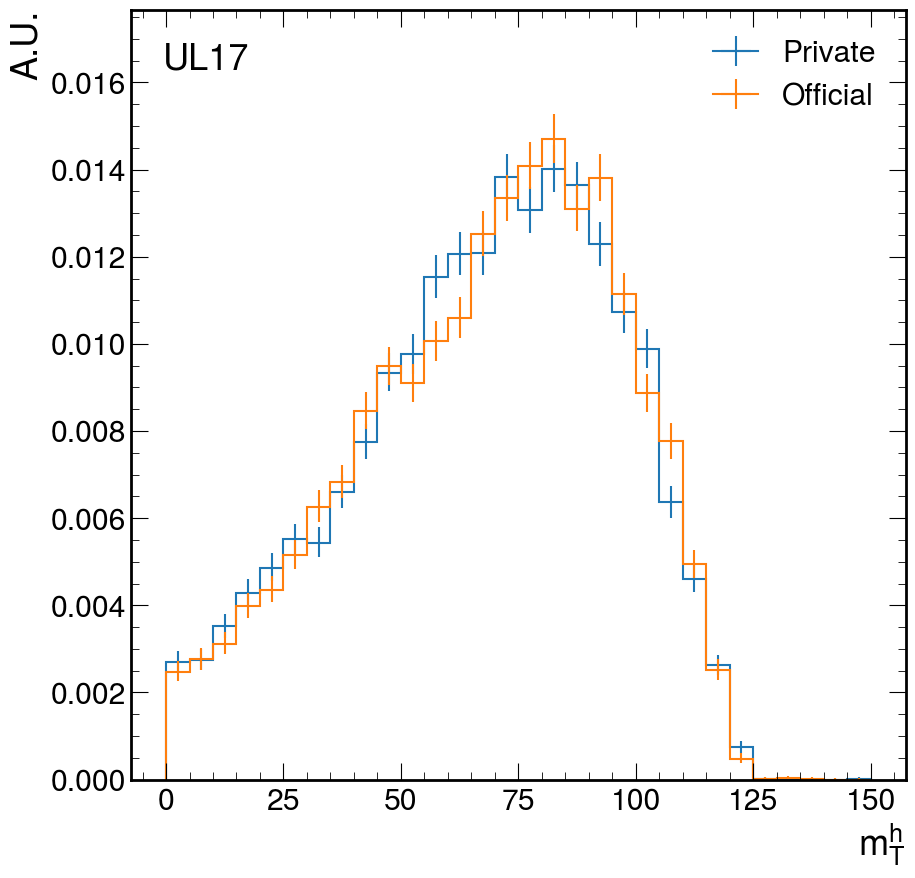

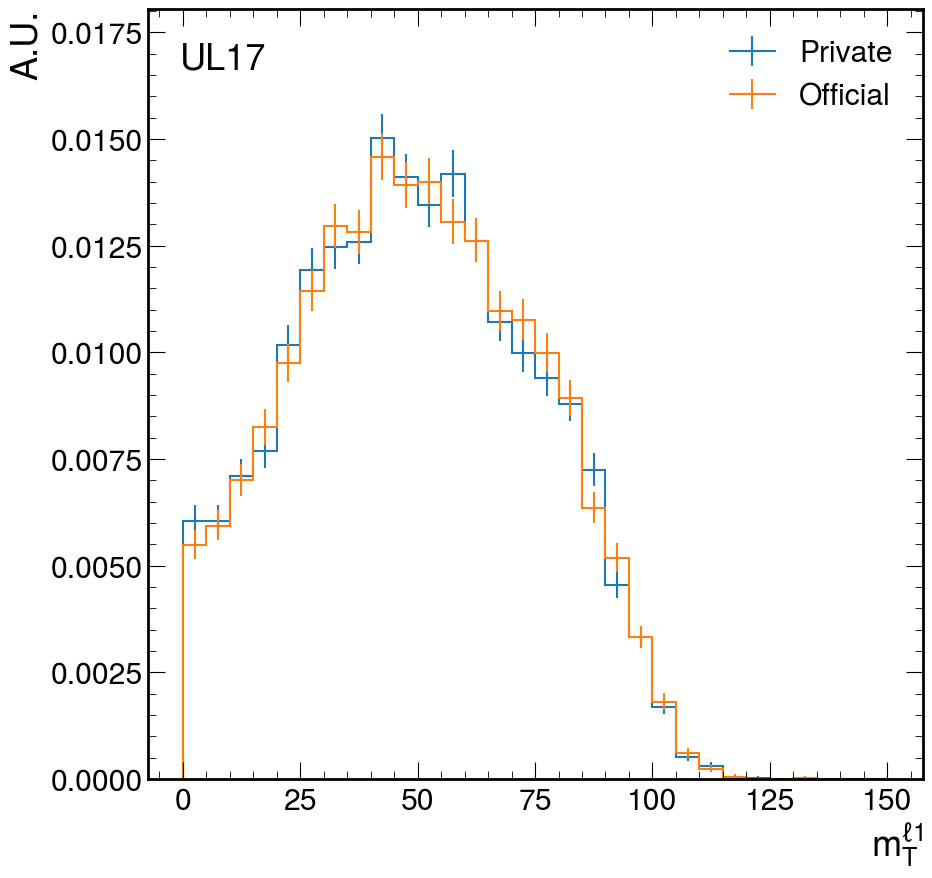

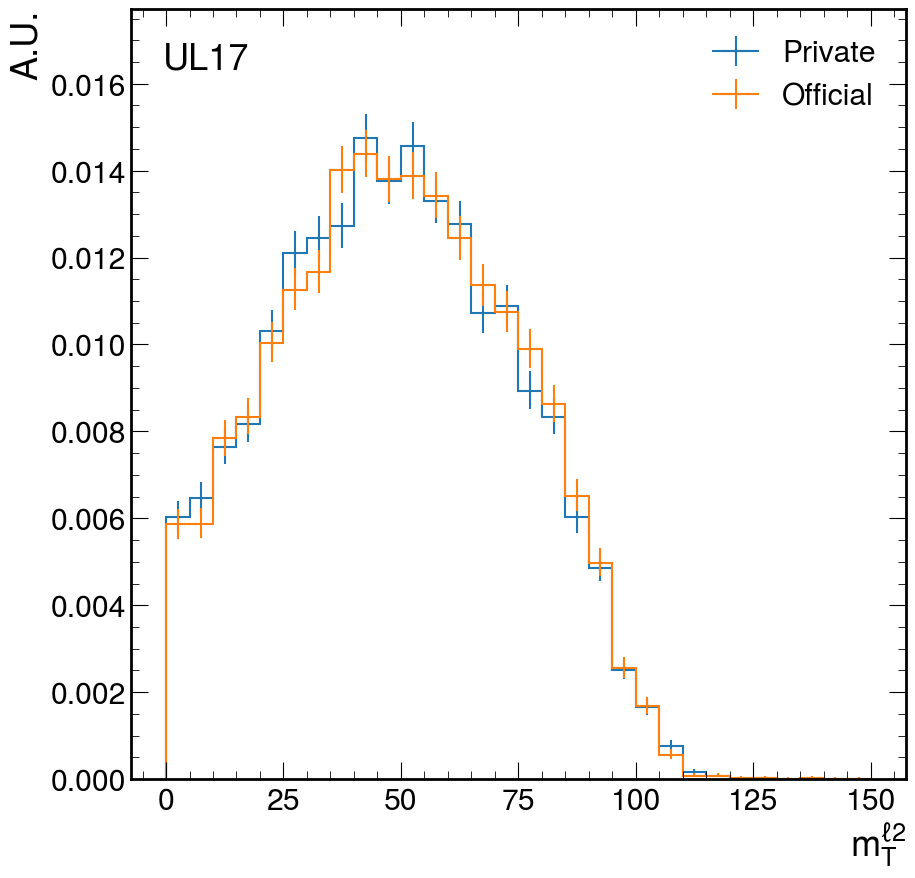

In [106]:
import numpy as np
def mT(obj1, obj2):
    return np.sqrt(2.0 * obj1.pt * obj2.pt * (1.0 - np.cos(obj1.phi - obj2.phi)))
mT_old={
    "$m_T^{h}$":[genmet,(W_lep[:,0]+W_lep[:,1])],
    "$m_T^{\\ell 1}$":[(W_lep[:,0]),genmet],
    "$m_T^{\\ell 2}$":[(W_lep[:,1]),genmet],
}
mT_new={
    "$m_T^{h}$":[genmet_new,(W_lep_new[:,0]+W_lep_new[:,1])],
    "$m_T^{\\ell 1}$":[(W_lep_new[:,0]),genmet_new],
    "$m_T^{\\ell 2}$":[(W_lep_new[:,1]),genmet_new],
}
for var in mT_old.keys():
    hold = hist.Hist.new.Reg(30,0,150).Weight()
    hnew = hist.Hist.new.Reg(30,0,150).Weight()
    fig,ax=plt.subplots()
    hold.fill(ak.flatten(mT(mT_old[var][0],mT_old[var][1]),axis=-1))
    hnew.fill(ak.flatten(mT(mT_new[var][0],mT_new[var][1]),axis=-1))
    hep.histplot([hold,hnew],label=['Private','Official'],ax=ax,flow=None,density=True)
    #         hep.histplot(hnew,label='new',ax=ax,flow=None)#,clear=False)
    ax.set_xlabel(var)
    ax.set_ylabel("A.U.")
    ax.legend()
    at = AnchoredText("UL17",  frameon=False,loc=2)
    ax.add_artist(at)
    hep.mpl_magic(ax=ax)
    fig.savefig(f'plot/GEN_0425_ULoff/{var}.pdf')

Text(0.5, 1.0, 'H pT (reconstruct from final state particles)')

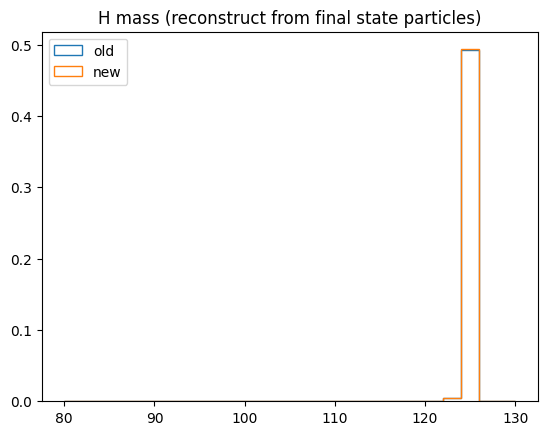

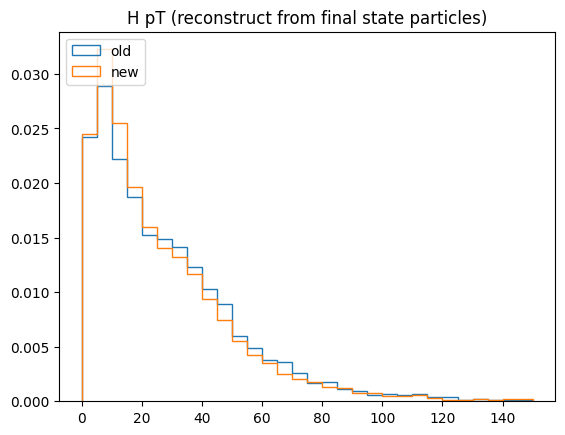

In [26]:
plt.figure()
plt.hist((W_lep[:,0]+W_lep[:,1]+W_neu[:,0]+W_neu[:,1]).mass,label="old",histtype='step',density=True,range=[80,130],bins=25)
plt.hist((W_lep_new[:,0]+W_lep_new[:,1]+W_neu_new[:,0]+W_neu_new[:,1]).mass,label="new",histtype='step',density=True,range=[80,130],bins=25)
plt.legend(loc=2)
plt.title("H mass (reconstruct from final state particles)")
plt.figure()
plt.hist(,label="old",histtype='step',density=True,range=[0,150],bins=30)
plt.hist((W_lep_new[:,0]+W_lep_new[:,1]+W_neu_new[:,0]+W_neu_new[:,1]).pt,label="new",histtype='step',density=True,range=[0,150],bins=30)
plt.legend(loc=2)
plt.title("H pT (reconstruct from final state particles)")

Text(0.5, 1.0, 'GEN c-Jet')

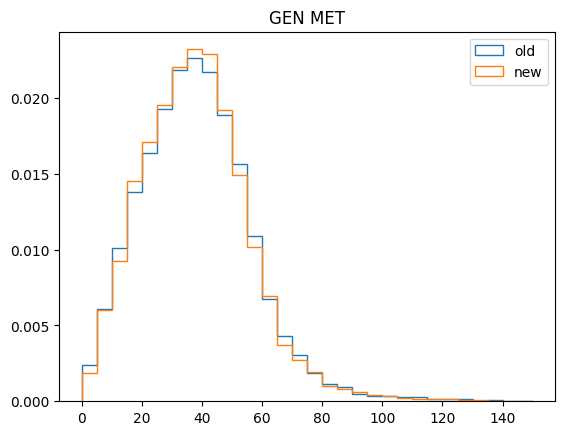

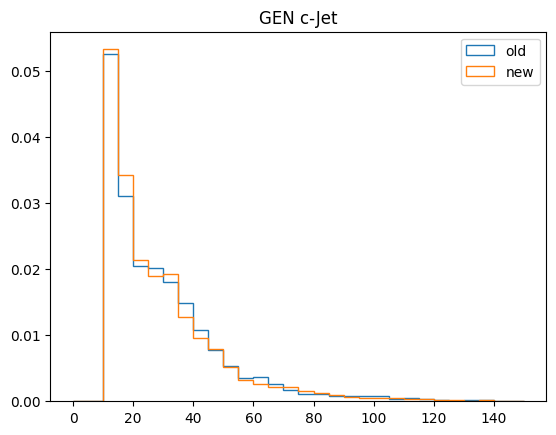

In [34]:

plt.figure()
plt.hist(ww["GenMET_pt"],label="old",histtype='step',density=True,range=[0,150],bins=30)
plt.hist(tt["GenMET_pt"],label="new",density=True,histtype='step',range=[0,150],bins=30)
plt.legend()
plt.title("GEN MET")
plt.figure()

plt.hist(ak.flatten(ww["GenJet_pt"][ww["GenJet_partonFlavour"]==4],axis=-1),label="old",histtype='step',density=True,range=[0,150],bins=30)
plt.hist(ak.flatten(tt["GenJet_pt"][tt["GenJet_partonFlavour"]==4],axis=-1),label="new",density=True,histtype='step',range=[0,150],bins=30)
plt.legend()
plt.title("GEN c-Jet")


NameError: name 'tau' is not defined

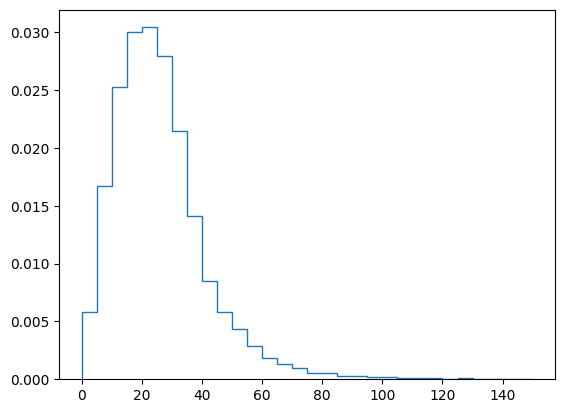

In [27]:
plt.figure()
plt.hist(ak.flatten(W.pt),label="WW",histtype='step',density=True,range=[0,150],bins=30)
plt.hist(ak.flatten(tau.pt),label="$\\tau\\tau$",density=True,histtype='step',range=[0,150],bins=30)
plt.legend()
plt.title("W/$\\tau$ pT")
plt.figure()
plt.hist(ak.flatten(W_lep.pt),label="WW",histtype='step',density=True,range=[0,150],bins=30)
plt.hist(ak.flatten(emu.pt),label="$\\tau\\tau$",density=True,histtype='step',range=[0,150],bins=30)
plt.legend()
plt.title("lepton pT")
plt.figure()
plt.hist(ak.flatten(W_neu.pt),label="WW",histtype='step',density=True,range=[0,150],bins=30)
plt.hist(ak.flatten(emuneu.pt),label="$\\tau\\tau(\\nu_e/\\nu_\\mu)$",density=True,histtype='step',range=[0,150],bins=30)
plt.hist(ak.flatten((emuneu+tauneu).pt),label="$\\tau\\tau(\\nu_e/\\nu_\\mu+\\nu_\\tau)$",density=True,histtype='step',range=[0,150],bins=30)
plt.legend()
plt.title("$\\nu$ pT")
plt.figure()
plt.hist((W_neu[:,0]+W_neu[:,1]).pt,label="WW",histtype='step',density=True,range=[0,150],bins=30)
plt.hist((emuneu[:,0]+emuneu[:,1]).pt,label="$\\tau\\tau(\\nu_e/\\nu_\\mu)$",density=True,histtype='step',range=[0,150],bins=30)
plt.hist((emuneu[:,0]+emuneu[:,1]+tauneu[:,0]+tauneu[:,1]).pt,label="$\\tau\\tau(\\nu_e/\\nu_\\mu+\\nu_\\tau)$",density=True,histtype='step',range=[0,150],bins=30)
plt.hist(ww["GenMET_pt"],label="WW(MET)",histtype='step',density=True,range=[0,150],bins=30)
plt.hist(tt["GenMET_pt"],label="$\\tau\\tau$(MET)",density=True,histtype='step',range=[0,150],bins=30)
plt.legend()
plt.title("$\\sum\\nu$ pT")
plt.figure()

plt.hist(ww["GenMET_pt"],label="WW(MET)",histtype='step',density=True,range=[0,150],bins=30)
plt.hist(tt["GenMET_pt"],label="$\\tau\\tau$(MET)",density=True,histtype='step',range=[0,150],bins=30)
plt.legend()
plt.title("$\\sum\\nu$ pT")
plt.figure()
plt.hist((W_neu[:,0]+W_neu[:,1]).pz,label="WW",histtype='step',density=True,range=[0,150],bins=30)
plt.hist((emuneu[:,0]+emuneu[:,1]).pz,label="$\\tau\\tau(\\nu_e/\\nu_\\mu)$",density=True,histtype='step',range=[0,150],bins=30)
plt.hist((emuneu[:,0]+emuneu[:,1]+tauneu[:,0]+tauneu[:,1]).pz,label="$\\tau\\tau(\\nu_e/\\nu_\\mu+\\nu_\\tau)$",density=True,histtype='step',range=[0,150],bins=30)


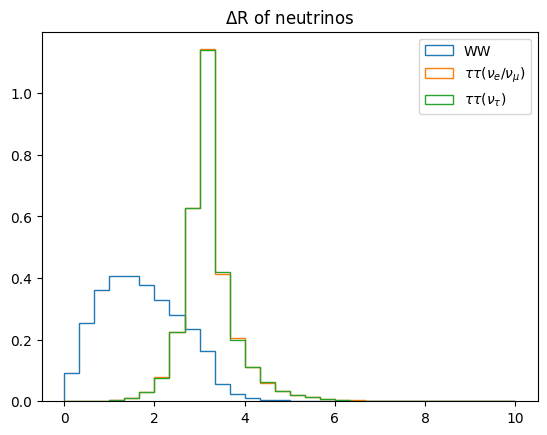

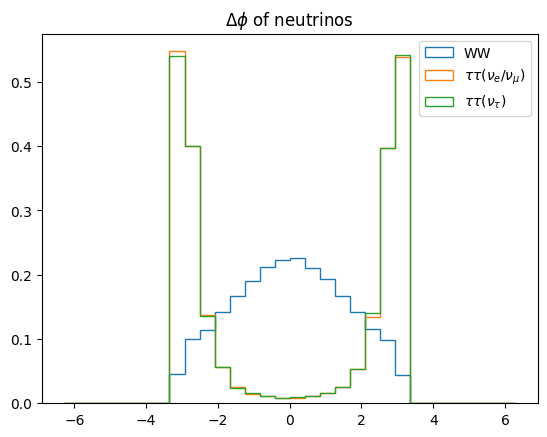

In [19]:
plt.title("$\Delta$R of neutrinos")
plt.hist(W_neu[:,0].deltaR(W_neu[:,1]),label="WW",histtype='step',density=True,range=[0,10],bins=30)
plt.hist(emuneu[:,0].deltaR(emuneu[:,1]),label="$\\tau\\tau(\\nu_e/\\nu_\\mu)$",histtype='step',density=True,range=[0,10],bins=30)
plt.hist(tauneu[:,0].deltaR(tauneu[:,1]),label="$\\tau\\tau(\\nu_\\tau)$",histtype='step',density=True,range=[0,10],bins=30)
plt.legend()
plt.figure()
import numpy as np
plt.title("$\Delta\phi$ of neutrinos")
plt.hist(W_neu[:,0].deltaphi(W_neu[:,1]),label="WW",histtype='step',density=True,range=[-2*np.pi,2*np.pi],bins=30)
plt.hist(emuneu[:,0].deltaphi(emuneu[:,1]),label="$\\tau\\tau(\\nu_e/\\nu_\\mu)$",histtype='step',density=True,range=[-2*np.pi,2*np.pi],bins=30)
plt.hist(tauneu[:,0].deltaphi(tauneu[:,1]),label="$\\tau\\tau(\\nu_\\tau)$",histtype='step',density=True,range=[-2*np.pi,2*np.pi],bins=30)
plt.legend()

In [20]:
W_allneu=vector.arr(ak.zip({
    "pt":ww['GenPart_pt'][((ww['GenPart_statusFlags']>>13&1)==1)&((abs(ww['GenPart_pdgId'])==12)|(abs(ww['GenPart_pdgId'])==14)|(abs(ww['GenPart_pdgId'])==16))],
     "eta":ww['GenPart_eta'][((ww['GenPart_statusFlags']>>13&1)==1)&((abs(ww['GenPart_pdgId'])==12)|(abs(ww['GenPart_pdgId'])==14)|(abs(ww['GenPart_pdgId'])==16))],
     "phi":ww['GenPart_phi'][((ww['GenPart_statusFlags']>>13&1)==1)&((abs(ww['GenPart_pdgId'])==12)|(abs(ww['GenPart_pdgId'])==14)|(abs(ww['GenPart_pdgId'])==16))],
     "mass":ww['GenPart_mass'][((ww['GenPart_statusFlags']>>13&1)==1)&((abs(ww['GenPart_pdgId'])==12)|(abs(ww['GenPart_pdgId'])==14)|(abs(ww['GenPart_pdgId'])==16))],
}))
tau_allneu=vector.arr(ak.zip({
    "pt":tt['GenPart_pt'][((tt['GenPart_statusFlags']>>13&1)==1)&((abs(tt['GenPart_pdgId'])==12)|(abs(tt['GenPart_pdgId'])==14)|(abs(tt['GenPart_pdgId'])==16))],
     "eta":tt['GenPart_eta'][((tt['GenPart_statusFlags']>>13&1)==1)&((abs(tt['GenPart_pdgId'])==12)|(abs(tt['GenPart_pdgId'])==14)|(abs(tt['GenPart_pdgId'])==16))],
     "phi":tt['GenPart_phi'][((tt['GenPart_statusFlags']>>13&1)==1)&((abs(tt['GenPart_pdgId'])==12)|(abs(tt['GenPart_pdgId'])==14)|(abs(tt['GenPart_pdgId'])==16))],
     "mass":tt['GenPart_mass'][((tt['GenPart_statusFlags']>>13&1)==1)&((abs(tt['GenPart_pdgId'])==12)|(abs(tt['GenPart_pdgId'])==14)|(abs(tt['GenPart_pdgId'])==16))],
}))
# ww['GenPart_pdgId'][((ww['GenPart_statusFlags']>>13&1)==1)&((abs(ww['GenPart_pdgId'])==12)|(abs(ww['GenPart_pdgId'])==14)|(abs(ww['GenPart_pdgId'])==16))]
# print(ak.type(W_allneu))
# print(W_allneu[0].pt.to_list())

# plt.figure()
# plt.hist(ak.flatten(tauneu.pt),label="$\\nu_\\tau$",histtype='step',range=[0,150],bins=30)
# plt.hist(ak.flatten((emuneu+emu).pt),label="$\\ell+\\nu$",histtype='step',range=[0,150],bins=30)
# plt.legend()

158301 * {"rho": float32, "phi": float32, "eta": float32, "tau": float32}


<Figure size 640x480 with 0 Axes>

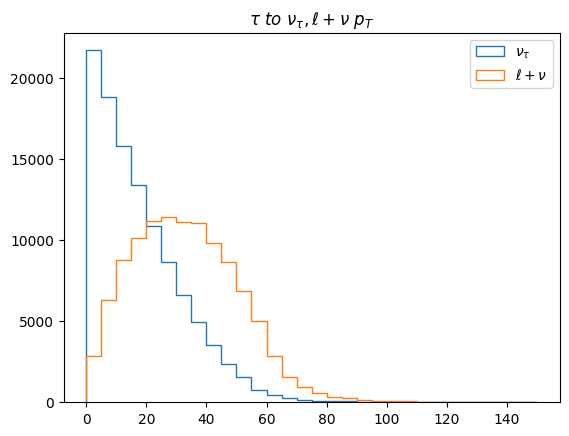

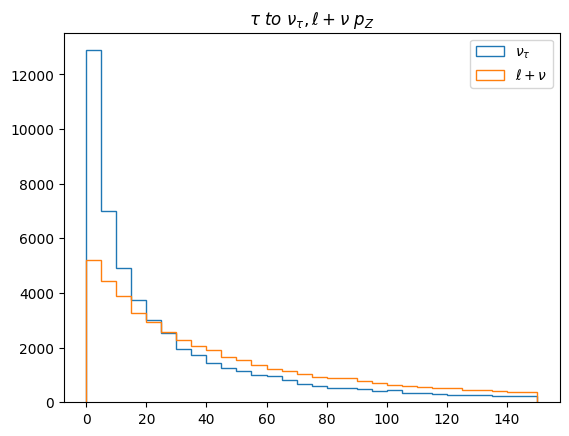

<Figure size 640x480 with 0 Axes>

In [25]:
plt.figure()
plt.hist(ak.flatten(tauneu.pt),label="$\\nu_\\tau$",histtype='step',range=[0,150],bins=30)
plt.hist(ak.flatten((emuneu+emu).pt),label="$\\ell+\\nu$",histtype='step',range=[0,150],bins=30)
plt.legend()
plt.title("$\\tau\ to\ \\nu_\\tau,\\ell+\\nu\ p_T$ ")
plt.figure()
plt.hist(ak.flatten(tauneu.pz),label="$\\nu_\\tau$",histtype='step',range=[0,150],bins=30)
plt.hist(ak.flatten((emuneu+emu).pz),label="$\\ell+\\nu$",histtype='step',range=[0,150],bins=30)
plt.legend()
plt.title("$\\tau\ to\ \\nu_\\tau,\\ell+\\nu\ p_Z$ ")
plt.figure()
# plt.hist(ak.flatten(tauneu.p),label="$\\nu_\\tau$",histtype='step',range=[0,150],bins=30)
# plt.hist(ak.flatten((emuneu+emu).p),label="$\\ell+\\nu$",histtype='step',range=[0,150],bins=30)
# plt.legend()
# plt.title("$\\tau\ to\ \\nu_\\tau,\\ell+\\nu\ p$ ")


In [ ]:
# ww_nohard=((ww['GenPart_statusFlags']>>13&1)==1)&((ww['GenPart_statusFlags']>>9&1)==0)&((ww['GenPart_statusFlags']>>7&1)==0)&((abs(ww['GenPart_pdgId'])==12)|(abs(ww['GenPart_pdgId'])==14)|(abs(ww['GenPart_pdgId'])==16))
# tt_nohard=((tt['GenPart_statusFlags']>>13&1)==1)&((tt['GenPart_statusFlags']>>9&1)==0)&((abs(tt['GenPart_pdgId'])==12)|(abs(tt['GenPart_pdgId'])==14)|(abs(tt['GenPart_pdgId'])==16))
# print(ww['GenPart_pt'][((ww['GenPart_statusFlags']>>13&1)==1)&((ww['GenPart_statusFlags']>>9&1)==0)&((ww['GenPart_statusFlags']>>7&1)==0)&((abs(ww['GenPart_pdgId'])==12)|(abs(ww['GenPart_pdgId'])==14)|(abs(ww['GenPart_pdgId'])==16))][2])
# print(ww['GenPart_pdgId'][((ww['GenPart_statusFlags']>>13&1)==1)&((ww['GenPart_statusFlags']>>9&1)==0)&((ww['GenPart_statusFlags']>>7&1)==0)&((abs(ww['GenPart_pdgId'])==12)|(abs(ww['GenPart_pdgId'])==14)|(abs(ww['GenPart_pdgId'])==16))][2])
# plt.figure()
# [(abs(ww['GenPart_pdgId'][ww['GenPart_genPartIdxMother'][ww_nohard&abs(ww['GenPart_pdgId'])]])>400)&(abs(ww['GenPart_pdgId'][ww['GenPart_genPartIdxMother'][ww_nohard&abs(ww['GenPart_pdgId'])]])<4000)]
# ww['GenPart_pdgId'][ww['GenPart_genPartIdxMother'][(ww['GenPart_pdgId']==22)]]
import numpy as np
np.unique(ak.flatten(ww['GenPart_statusFlags'][(ww['GenPart_pdgId']==22)]).tolist())

# plt.hist(ak.flatten(ww['GenPart_pt'][(abs(ww['GenPart_pdgId'][ww['GenPart_genPartIdxMother'][ww_nohard&abs(ww['GenPart_pdgId'])]])>400)&(abs(ww['GenPart_pdgId'][ww['GenPart_genPartIdxMother'][ww_nohard&abs(ww['GenPart_pdgId'])]])<4000)]),range=[0,150],label='WW b/c mesons',histtype='step',density=True)
# plt.hist(ak.flatten(ww['GenPart_pt'][(abs(ww['GenPart_pdgId'][ww['GenPart_genPartIdxMother'][ww_nohard&abs(ww['GenPart_pdgId'])]])==12)]),range=[0,150],label='WW $\\nu_e$',histtype='step',density=True)
# plt.hist(ak.flatten(ww['GenPart_pt'][(abs(ww['GenPart_pdgId'][ww['GenPart_genPartIdxMother'][ww_nohard&abs(ww['GenPart_pdgId'])]])==14)]),range=[0,150],label='WW $\\nu_\mu$',histtype='step',density=True)
# plt.hist(ak.flatten(ww['GenPart_pt'][(abs(ww['GenPart_pdgId'][ww['GenPart_genPartIdxMother'][ww_nohard&abs(ww['GenPart_pdgId'])]])==15)]),range=[0,150],label='WW $\\tau$',histtype='step',density=True)
# plt.hist(ak.flatten(ww['GenPart_pt'][(abs(ww['GenPart_pdgId'][ww['GenPart_genPartIdxMother'][ww_nohard&abs(ww['GenPart_pdgId'])]])==16)]),range=[0,150],label='WW $\\nu_\tau$',histtype='step',density=True)
# plt.hist(ak.flatten(tt['GenPart_pt'][(abs(tt['GenPart_pdgId'][tt['GenPart_genPartIdxMother'][tt_nohard&abs(tt['GenPart_pdgId'])]])>400)&(abs(tt['GenPart_pdgId'][tt['GenPart_genPartIdxMother'][tt_nohard&abs(tt['GenPart_pdgId'])]])<4000)]),range=[0,150],label='$\\tau\\tau$ b/c mesons',histtype='step',density=True)
# plt.legend(loc=4,ncol=2)
# import numpy as np
# np.set_printoptions(threshold=np.inf)
# arr=np.unique(abs(ak.flatten(ww['GenPart_pdgId'][ww['GenPart_genPartIdxMother'][ww_nohard]]))).tolist()
# arr
# ww['GenPart_pdgId'][(abs(ww['GenPart_pdgId'][ww['GenPart_genPartIdxMother'][ww_nohard]])<1000)&(abs(ww['GenPart_pdgId'][ww['GenPart_genPartIdxMother'][ww_nohard]])>500)].to_list()
# plt.figure()
# tt['GenPart_pdgId'][tt['GenPart_genPartIdxMother'][tt_nohard]]

In [155]:
from coffea import processor
import hist
import awkward as ak
class MyProcessor(processor.ProcessorABC):
    def __init__(self):
        pass

    def process(self, events):
        dataset = events.metadata['dataset']
        allneu=events.GenPart[((abs(events.GenPart.pdgId)==12)|(abs(events.GenPart.pdgId)==14)|(abs(events.GenPart.pdgId)==16))&(events.GenPart.hasFlags(["isLastCopy"]) == True)]
#         print(sum(allneu))
        sumallneu=allneu.sum(axis=1)
        print(sumallneu.pt)
        notfromHP=((abs(events.GenPart.pdgId)==12)|(abs(events.GenPart.pdgId)==14)|(abs(events.GenPart.pdgId)==16)) & ((events.GenPart.hasFlags(["isHardProcessTauDecayProduct"]) == False)|(events.GenPart.hasFlags(["isHardProcess"]) == False)|(events.GenPart.hasFlags(["fromHardProcess"]) == False)|(events.GenPart.hasFlags(["isDirectHardProcessTauDecayProduct"]) == False))&(events.GenPart.hasFlags(["isLastCopy"]) == True)
        
        if 'W' in dataset: 
            fromHP = ((abs(events.GenPart.pdgId)==12)|(abs(events.GenPart.pdgId)==14)) & (events.GenPart.hasFlags(["isHardProcess"]) == True)&(events.GenPart.hasFlags(["fromHardProcess"]) == True)&(events.GenPart.hasFlags(["isLastCopy"]) == True)&(events.GenPart.hasFlags(["isHardProcessTauDecayProduct"]) == False)&(events.GenPart.hasFlags(["isDirectHardProcessTauDecayProduct"]) == False)
        else :fromHP = ((abs(events.GenPart.pdgId)==12)|(abs(events.GenPart.pdgId)==14)) & ((events.GenPart.hasFlags(["isHardProcessTauDecayProduct"]) == True)&(events.GenPart.hasFlags(["isDirectHardProcessTauDecayProduct"]) == True))&(events.GenPart.hasFlags(["isLastCopy"]) == True)
            
        
#         print(events.GenPart.hasFlags(["isHardProcessTauDecayProduct","isHardProcess"]),events.GenPart.hasFlags(["isHardProcessTauDecayProduct"]))
        #& (events.GenPart.hasFlags['isLastCopy']==True) & ( events.GenPart.hasFlags['isHardProcess']==False) & (events.GenPart.hasFlags['isHardProcessTauDecayProduct']==False)
        tau_from_W=events.GenPart[(abs(events.GenPart.pdgId)==15)&((events.GenPart.hasFlags(["isHardProcess"]) == True)&(events.GenPart.hasFlags(["fromHardProcess"]) == True))]#& (abs(events.GenPart.parent.pdgId)==24)]
#         nW=ak.full_like(events.genWeight,True)
        
        
        neu_not_from_HP=events.GenPart[notfromHP]
        neu_from_HP = events.GenPart[fromHP]
        nW=ak.num(neu_from_HP.pt)==2
        
        if 'W' in dataset:nW=ak.num(tau_from_W.pt)==0
        
        print(ak.num(neu_from_HP.pt))
        print(dataset,ak.any(ak.num(tau_from_W.pt)>1),nW,neu_not_from_HP.pt,neu_from_HP.pt)
        neu_notHP_pt = (
            hist.Hist.new
#             .IntCategory([], name="mompdgId",growth=True)
#             .IntCategory([12,14,16], name="pdgId",growth=True)
#             .IntCategory([], name="momflags",growth=True)
            .IntCategory([0,1], name="isHardProcess",growth=True)
            .IntCategory([0,1], name="fromHardProcess",growth=True)
            .IntCategory([0,1], name="isHardProcessTauDecayProduct",growth=True)
            .IntCategory([0,1], name="isDirectHardProcessTauDecayProduct",growth=True)
            .IntCategory([0,1], name="notau",growth=True)
            .Regular(30, 0, 150., name="pt", label="$\\nu p_T$ [GeV]")
            .Int64()
            
        )
        genmet=(hist.Hist.new
                .IntCategory([0,1], name="notau",growth=True)
                .Regular(30, 0, 150., name="pt", label="$\\nu p_T$ [GeV]")
            .Int64())
        genallmu=(hist.Hist.new
                .IntCategory([0,1], name="notau",growth=True)
                .Regular(30, 0, 150., name="pt", label="$\\nu p_T$ [GeV]")
            .Int64())
        neu_HP_pt = (
            hist.Hist.new
#             .IntCategory([], name="mompdgId",growth=True)
#             .IntCategory([12,14,16], name="pdgId",growth=True)
#             .IntCategory([], name="momflags",growth=True)
            .IntCategory([0,1], name="notau",growth=True)
            .Regular(30, 0, 150., name="pt", label="$\\nu p_T$ [GeV]")
            .Int64()
            
        )
        neu_notHP_pt.fill(isHardProcess=ak.flatten(neu_not_from_HP.hasFlags(["isHardProcess"])),fromHardProcess=ak.flatten(neu_not_from_HP.hasFlags(["fromHardProcess"])),isHardProcessTauDecayProduct=ak.flatten(neu_not_from_HP.hasFlags(["isHardProcessTauDecayProduct"])),isDirectHardProcessTauDecayProduct=ak.flatten(neu_not_from_HP.hasFlags(["isDirectHardProcessTauDecayProduct"])),notau=ak.flatten(ak.broadcast_arrays(nW,neu_not_from_HP.pt)[0]),pt=ak.flatten(neu_not_from_HP.pt))
        neu_HP_pt.fill(notau=ak.flatten(ak.broadcast_arrays(nW,neu_from_HP.pt)[0]),pt=ak.flatten(neu_from_HP.pt))
        genmet.fill(notau=nW,pt=events.GenMET.pt)
        genallmu.fill(notau=nW,pt=sumallneu.pt)
#neu_pt.fill(mompdgId=ak.flatten(abs(neu_not_from_HP.parent.pdgId)),pdgId=ak.flatten(abs(neu_not_from_HP.pdgId)),momflags=ak.flatten(neu_not_from_HP.parent.statusFlags),flags=ak.flatten(neu_not_from_HP.statusFlags),pt=ak.flatten(neu_not_from_HP.pt))
#         neu_pt_notau.fill(mompdgId=ak.flatten(abs(neu_not_from_HP[events.GenPart.hasFlags(["isTauDecayProduct"])==False].parent.pdgId)),pdgId=ak.flatten(abs(neu_not_from_HP[events.GenPart.hasFlags(["isTauDecayProduct"])==False].pdgId)),pt=ak.flatten(neu_not_from_HP[events.GenPart.hasFlags(["isTauDecayProduct"])==False].pt))
        return {
            dataset: {
                
                "neu_notHP_pt": neu_notHP_pt,
                 "neu_HP_pt": neu_HP_pt,
                "genmet":genmet,
                "genallmu":genallmu,
            }
        }

    def postprocess(self, accumulator):
        pass

In [156]:
import uproot
from coffea.util import load, save
from coffea import processor



output = processor.run_uproot_job(                                                                          
            {"WW":["/nfs/dust/cms/user/milee/gchcWW2L2Nu_4F_NLO/gchcWW2L2Nu_4F_NLO_38864710.root"],
            "tau":["../HToTauTau2L2Nu/HToTauTau2L2Nu_0.root"]},                                                                                             
            treename="Events",                                                                                     
            processor_instance=MyProcessor(),                                                                    
            executor=processor.iterative_executor,                                                                 
            executor_args={                                                                                       
                "schema": processor.NanoAODSchema,                                                                 
            },                                                                                                     
            chunksize=10000000,                                                                                    
    )
save(output,"test_notau.coffea")

Output()

[21.3, 13.5, 17.2, 24.8, 77, 22.6, 33.5, ... 32.9, 5.09, 15, 7.09, 18, 19.2, 50.3]

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ... 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

tau True [True, True, True, True, True, True, True, ... True, True, True, True, True, True] [[8.41, 23.1, 5.45, 
6.62], [34, 1.48, ... 0.0627], [23.8, 32, 2.74, 2.36, 0.746]] [[23.1, 6.62], [1.48, 25.3], [8.31, 28.2], ... 37.5, 
13.8], [8.22, 3.32], [32, 2.36]]

[34.8, 17.5, 20.7, 28.7, 6.4, 10.5, 17.4, ... 66.1, 33, 48.5, 47.1, 25.8, 24.1, 12.6]

[0, 2, 0, 1, 1, 1, 0, 1, 0, 2, 1, 0, 0, 1, ... 1, 1, 2, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0]

WW True [False, True, True, False, False, True, ... False, True, False, False, False, False] [[31.3, 14.3, 5.44, 
6.25, 0.803, 1.28], ... [29.8, 21.1, 1.07, 23.6, 4.69, 0.331]] [[], [11.9, 30.1], [], [51], [17.4], [22.6, ... 
[32.2], [28.6], [], [], [], []]

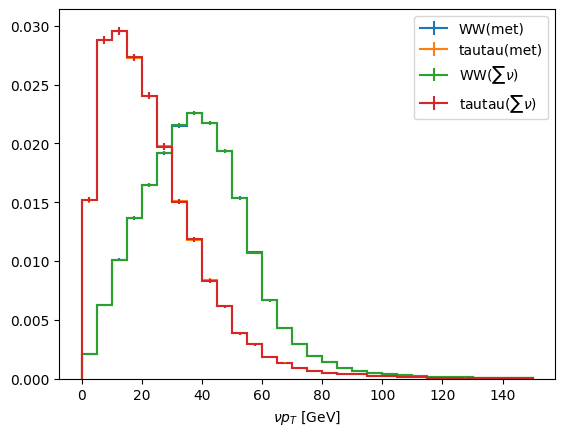

In [158]:
from coffea.util import load
output=load('test_notau.coffea')
import mplhep as hep
"Reco H":(W_lep[:,0]+W_lep[:,1]+W_neu[:,0]+W_neu[:,1]),import matplotlib.pyplot as plt
#[0]#[0,0,0,0,1]
# set1=output['WW']['neu_notHP_pt'][{"isHardProcess":0,"fromHardProcess":0,"isHardProcessTauDecayProduct":0,"isDirectHardProcessTauDecayProduct":0,"notau":1}]
# set2=output['WW']['neu_notHP_pt'][{"isHardProcess":0,"fromHardProcess":1,"isHardProcessTauDecayProduct":0,"isDirectHardProcessTauDecayProduct":0,"notau":1}]
# set3=output['WW']['neu_notHP_pt'][{"isHardProcess":0,"fromHardProcess":0,"isHardProcessTauDecayProduct":0,"isDirectHardProcessTauDecayProduct":1,"notau":1}]

# hep.histplot(set1,label='WW(!flag1&!flag2&!flag3&!flag4)',density=True)
# hep.histplot(set2,label='WW(!flag1&flag2&!flag3&!flag4)',density=True)
# hep.histplot(set3,label='WW(!flag1&!flag2&flag3&!flag4)',density=True)
# hep.histplot(output['tau']['neu_notHP_pt'],label='tautau',density=True)
hep.histplot(output['WW']['genmet'][{'notau':sum}],label='WW(met)',density=True)
hep.histplot(output['tau']['genmet'][{'notau':sum}],label='tautau(met)',density=True)
hep.histplot(output['WW']['genallmu'][{'notau':sum}],label='WW($\\sum\\nu$)',density=True)
hep.histplot(output['tau']['genallmu'][{'notau':sum}],label='tautau($\\sum\\nu$)',density=True)
# plt.text(0.3,0.01,"flag1: isHardProcess\nflag2: fromHardProcess\nflag3: isHardProcessTauDecayProduct\nflag4: isDirectHardProcessTauDecayProduct")
plt.legend()
# wwlist=[421, 431, 411, 4122, 511, 15, 521, 4232, 5122, 531, 4132, 14, 5132, 5232, 16, 4424, 4332, 4414, 541]#[14, 421, 431, 411, 4122, 16, 511, 12, 15, 521, 4232, 5122, 531, 4132, 5132, 5232, 4424, 4332, 4414, 541]
# wwnum=[i for i in range(len(wwlist))]
# taulist=[421, 431, 15, 411, 511, 4122, 4132, 521, 4232, 531, 5132, 5232, 14, 541, 5122, 16]

# taunum=[i for i in range(len(taulist))]
# wdict = dict(zip(wwlist, wwnum))
# taudict = dict(zip(taulist,taunum))
# print(output['WW']['neupt'].sort(0).axes[0])
# print(wdict[12])
# output['WW']['neupt'][{'mompdgId':wdict[16]}]#.plot()
# plt.figure()
# hep.histplot(output['WW']['neupt'][{'mompdgId':wdict[421],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[411],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[431],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[4122],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[4132],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[4232],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[4332],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[4414],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[4424],'pdgId':sum}],label='WW (charmed hadrons)')
# hep.histplot(output['WW']['neupt'][{'mompdgId':wdict[511],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[521],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[531],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[541],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[5122],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[5132],'pdgId':sum}]+output['WW']['neupt'][{'mompdgId':wdict[5232],'pdgId':sum}],label='WW (bottom hadrons)')
# hep.histplot(output['WW']['neupt'][{'mompdgId':wdict[12],'pdgId':sum,'flags':sum}],label="WW $\\nu_e\\rightarrow\\nu_e$")
# hep.histplot(output['WW']['neupt'][{'mompdgId':wdict[14],'pdgId':sum,'flags':sum}],label="WW $\\nu_\\mu\\rightarrow\\nu_\\mu$")
# hep.histplot(output['WW']['neupt'][{'mompdgId':wdict[16],'pdgId':sum,'flags':sum}],label="WW $\\nu_\\tau\\rightarrow\\nu_\\tau$")
# hep.histplot(output['WW']['neupt'][{'mompdgId':wdict[15],'pdgId':sum,'flags':sum}],label="WW $\\tau\\rightarrow(\\nu_e,\\nu_\\mu,\\nu_\\tau)$")
# plt.xlabel('$\\nu pT$')
# # plt.yscale("log")
# plt.legend(ncol=2)
# output['WW']['neupt'][{'mompdgId':wdict[14],'pdgId':1}]
# output['tau']['neupt']

In [65]:
print(output['tau']['neupt'].sort(0).axes[0])
# hep.histplot(output['tau']['neupt'][{'mompdgId':taudict[421],'pdgId':sum}]+output['tau']['neupt'][{'mompdgId':taudict[411],'pdgId':sum}]+output['tau']['neupt'][{'mompdgId':taudict[431],'pdgId':sum}]+output['tau']['neupt'][{'mompdgId':taudict[4122],'pdgId':sum}]+output['tau']['neupt'][{'mompdgId':taudict[4132],'pdgId':sum}]+output['tau']['neupt'][{'mompdgId':taudict[4232],'pdgId':sum}],label='$\\tau\\tau$ (charmed hadrons)')
# hep.histplot(output['tau']['neupt'][{'mompdgId':taudict[511],'pdgId':sum}]+output['tau']['neupt'][{'mompdgId':taudict[521],'pdgId':sum}]+output['tau']['neupt'][{'mompdgId':taudict[531],'pdgId':sum}]+output['tau']['neupt'][{'mompdgId':taudict[541],'pdgId':sum}]+output['tau']['neupt'][{'mompdgId':taudict[5122],'pdgId':sum}]+output['tau']['neupt'][{'mompdgId':taudict[5132],'pdgId':sum}]+output['tau']['neupt'][{'mompdgId':taudict[5232],'pdgId':sum}],label='$\\tau\\tau$ (bottom hadrons)')
hep.histplot(output['tau']['neupt'][{'mompdgId':taudict[12],'pdgId':0}],label="$\\tau\\tau$ $\\nu_e\\rightarrow\\nu_e$")
hep.histplot(output['tau']['neupt'][{'mompdgId':taudict[14],'pdgId':1}],label="$\\tau\\tau$ $\\nu_\\mu\\rightarrow\\nu_\\mu$")
hep.histplot(output['tau']['neupt'][{'mompdgId':taudict[15],'pdgId':sum}],label="$\\tau\\tau$ $\\tau\\rightarrow(\\nu_e,\\nu_\\mu,\\nu_\\tau)$")
hep.histplot(output['tau']['neupt'][{'mompdgId':taudict[16],'pdgId':2}],label="$\\tau\\tau$ $\\nu_\\tau\\rightarrow\\nu_\\tau$")
plt.legend()
plt.yscale("log")

KeyError: 'neupt'

In [162]:
FLAGS= ['isPrompt', 'isDecayedLeptonHadron', 'isTauDecayProduct', 'isPromptTauDecayProduct', 'isDirectTauDecayProduct', 'isDirectPromptTauDecayProduct', 'isDirectHadronDecayProduct', 'isHardProcess', 'fromHardProcess', 'isHardProcessTauDecayProduct', 'isDirectHardProcessTauDecayProduct', 'fromHardProcessBeforeFSR', 'isFirstCopy', 'isLastCopy', 'isLastCopyBeforeFSR']
flag=[i for i in range(len(FLAGS))]
# flag_dict=dict(zip(flag,FLAGS))
ttlists=[8451, 12675, 12291, 12354, 4160, 8258]
wwlists=[10497, 4481, 12675, 12291, 12354, 14721, 29059, 8451, 4160, 28738, 8258, 8195, 24579, 12290]
dau=[12289]#352, 12308, 8256, 12348]
for ww in dau:#tt in ttlists:
    for i in range(len(flag)):
#         if (tt>>i&1)==1:print(tt,FLAGS[i])
#     for ww in wwlists:
        if (ww>>i&1)==1:print(ww,FLAGS[i])

# output['tau']['neupt'][{'mompdgId':taudict[16],'pdgId':2,'flags':8451>>3&1}]
# output['WW']['neupt'][{'mompdgId':wdict[15],'pdgId':sum,}]
# hep.histplot(output['WW']['neupt'][{'mompdgId':wdict[12],'pdgId':0}],label="WW $\\nu_e\\rightarrow\\nu_e$")
# hep.histplot(output['WW']['neupt'][{'mompdgId':wdict[14],'pdgId':1}],label="WW $\\nu_\\mu\\rightarrow\\nu_\\mu$")
# hep.histplot(output['WW']['neupt'][{'mompdgId':wdict[16],'pdgId':2}],label="WW $\\nu_\\tau\\rightarrow\\nu_\\tau$")
# hep.histplot(output['WW']['neupt'][{'mompdgId':wdict[15],'pdgId':sum}],label="WW $\\tau\\rightarrow(\\nu_e,\\nu_\\mu,\\nu_\\tau)$")
# plt.xlabel('$\\nu pT$')
# # plt.yscale("log")
# plt.legend(ncol=2)

12289 isPrompt
12289 isFirstCopy
12289 isLastCopy


In [18]:
output['WW']['neupt']

Hist(
  IntCategory([24, 14, 15, 421, 431, 411, 4122, 16, 511, 12, 521, 4232, 5122, 531, 4132, 5132, 5232, 4424, 4332, 4414, 541], growth=True, name='mompdgId'),
  IntCategory([12, 14, 16], growth=True, name='pdgId'),
  IntCategory([10497, 4481, 12675, 12291, 12354, 14721, 29059, 8451, 4160, 28738, 8258, 8195, 24579, 12290], growth=True, name='flags'),
  Regular(30, 0, 150, name='pt', label='$\neu p_T$ [GeV]'),
  storage=Int64()) # Sum: 558897.0 (558954.0 with flow)

In [56]:
output['tau']['neupt']

Hist(
  IntCategory([421, 431, 15, 411, 511, 4122, 4132, 521, 4232, 531, 5132, 5232, 14, 541, 5122, 16], growth=True, name='mompdgId'),
  IntCategory([12, 14, 16], growth=True, name='pdgId'),
  IntCategory([12352, 12308, 8256, 12348], growth=True, name='flags'),
  Regular(30, 0, 150, name='pt', label='$\neu p_T$ [GeV]'),
  storage=Int64()) # Sum: 36112.0

## Check ggH contribution

In [26]:
import uproot
hb=uproot.open("root://eoscms.cern.ch//eos/cms///store/mc/RunIISummer20UL18NanoAODv9/HPlusBottom_5FS_MuRFScaleDynX0p50_HToWWTo2L2Nu_M125_TuneCP5_13TeV-amcatnloFXFX-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v1/40000/B5E7ABA0-98A0-9E45-8356-AB8209D145B1.root:Events")
ggh=uproot.open("root://xrootd.hep.kbfi.ee:1094///store/mc/RunIISummer20UL18NanoAODv9/GluGluHToWWTo2L2Nu_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v2/260000/074B5A6F-2238-204D-8DB0-2F4B91C45093.root:Events")


In [35]:
hb_LHE=hb.arrays(filter_name=["*LHE*","event"])
ggh_LHE=ggh.arrays(filter_name=["*LHE*","event"])

In [36]:
import awkward as ak
hb_LHE=hb_LHE[:4000]
# hb_LHE.LHEPart_pdgId[hb_LHE.LHEPart_status==-1]

Text(0.5, 0, 'PDGID')

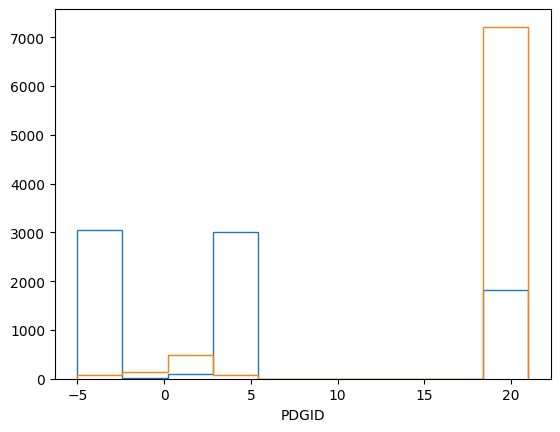

In [38]:
import matplotlib.pyplot as plt
plt.hist(ak.flatten(hb_LHE.LHEPart_pdgId[(hb_LHE.LHEPart_status==-1)],axis=None),histtype='step',label='H+b')
plt.hist(ak.flatten(ggh_LHE.LHEPart_pdgId[(ggh_LHE.LHEPart_status==-1)],axis=None),histtype='step',label='ggH')
plt.xlabel("PDGID")

In [29]:
a=set(ak.flatten(hb_LHE.LHEPart_pdgId[hb_LHE.LHEPart_status==-1]))
b=set(ak.flatten(ggh_LHE.LHEPart_pdgId[ggh_LHE.LHEPart_status==-1]))

({-5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 21},
 {-5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 21})